In [ ]:
# Google Colab Drive Mount (skip when running locally)
# from google.colab import drive
# drive.mount('/content/drive')

# When running locally, set the working directory if needed
import os
print(f'Current directory: {os.getcwd()}')

In [ ]:
import ee
import geemap
import os
from dotenv import load_dotenv
from google.oauth2 import service_account

In [ ]:
import subprocess
import sys

# Library tambahan yang diperlukan
additional_packages = [
    'geopandas',
    'openpyxl',
    'xlsxwriter',
    'contextily',
    'mapclassify'
]

for package in additional_packages:
    try:
        __import__(package)
        print(f"✓ {package} sudah terinstal")
    except ImportError:
        print(f"⏳ Menginstal {package}...")
        subprocess.check_call([sys.executable, '-m', 'pip', 'install',
                              package, '--quiet'])
        print(f"✓ {package} berhasil diinstal")

print("\n✅ Semua library tambahan siap digunakan")

✓ geopandas sudah terinstal
✓ openpyxl sudah terinstal
⏳ Menginstal xlsxwriter...
✓ xlsxwriter berhasil diinstal
⏳ Menginstal contextily...
✓ contextily berhasil diinstal
✓ mapclassify sudah terinstal

✅ Semua library tambahan siap digunakan


In [ ]:
# Load environment variables from file.env
env_path = os.path.join(os.path.dirname(os.getcwd()), 'file.env')
load_dotenv(env_path)

# Get credentials from environment variables
project_id = os.getenv('GEE_PROJECT_ID')
service_account_email = os.getenv('GEE_SERVICE_ACCOUNT_EMAIL')
key_file = os.getenv('GEE_SERVICE_ACCOUNT_KEY_FILE')

print(f"Project ID: {project_id}")
print(f"Service Account: {service_account_email}")
print(f"Key File: {key_file}")

In [ ]:
# Initialize Earth Engine with service account credentials
credentials = service_account.Credentials.from_service_account_file(
    key_file,
    scopes=['https://www.googleapis.com/auth/earthengine']
)

ee.Initialize(credentials=credentials, project=project_id)
print(f"Earth Engine initialized with project: {project_id}")

In [ ]:
# Verify Earth Engine is initialized
try:
    info = ee.String('Earth Engine is ready!').getInfo()
    print(info)
except Exception as e:
    print(f'Error: {e}')
    print('Please check your credentials and run the initialization cell again.')

In [ ]:
import math
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Patch
import warnings
warnings.filterwarnings('ignore')

# Load the study area feature collection
klambu_ee = ee.FeatureCollection("projects/ee-ozdogan05/assets/indonesia/klambu_nonsaluran_tertiary")
# Grab the bounding box
box = klambu_ee.geometry().bounds()

print("\n" + "=" * 80)
print("LOAD DATA GPKG KLAMBU")
print("=" * 80)



# Set plotting style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 10

# Convert Earth Engine FeatureCollection to a Pandas DataFrame
# This allows for client-side pandas operations.
klambu_list = klambu_ee.getInfo()['features']
properties_list = [f['properties'] for f in klambu_list]
klambu_df = pd.DataFrame(properties_list)

# Pastikan norec adalah integer
klambu_df['norec'] = pd.to_numeric(klambu_df['norec'], errors='coerce').fillna(0).astype(int)

print(f"\n📊 Sample Data:")
print(klambu_df[['norec', 'nama', 'nomenklatu']].head())


LOAD DATA GPKG KLAMBU

📊 Sample Data:
   norec             nama        nomenklatu
0    469   B.K.Ki 10 ka 1    B.K.Ki 10 ka 1
1    472   B.K.Ki 11 ka 1    B.K.Ki 11 ka 1
2    952  B.Prte 2 1 ka 1  B.Prte 2. 1 ka 1
3    949    B.Prte 2 ki 1     B.Prte 2 ki 1
4    565    B.W 2. 7 ki 1     B.W 2. 7 ki 1


In [ ]:
import math

# Load the study area feature collection
klambu = ee.FeatureCollection("projects/ee-ozdogan05/assets/indonesia/klambu_nonsaluran_tertiary")
# Grab the bounding box
box = klambu.geometry().bounds()

# Landsat Collection 2 data cloud masking functions
def getQABits(image, start, end, newName):
    """
    A function that returns an image containing just the specified QA bits.

    Args:
        image - The QA Image to get bits from.
        start - The first bit position, 0-based.
        end   - The last bit position, inclusive.
        newName  - A name for the output image.
    """
    # Compute the bits we need to extract.
    pattern = 0
    for i in range(start, end + 1):
        pattern += int(math.pow(2, i))

    # Return a single band image of the extracted QA bits, giving the band
    # a new name.
    return (image.select([0], [newName])
                 .bitwiseAnd(pattern)
                 .rightShift(start))

def maskClouds(image):
    """Function to mask clouds in Landsat Collection 2 using internal masks"""
    pixelQA = image.select('QA_PIXEL')
    cloud = getQABits(pixelQA, 3, 3, 'cloud')
    cldShadow = getQABits(pixelQA, 4, 4, 'cloud_shadow')
    return (image.updateMask(cloud.eq(0))
                 .updateMask(cldShadow.eq(0))
                 .copyProperties(image)
                 .set('system:time_start', image.get('system:time_start')))

def scaleC2(image):
    """Function to scale Landsat C2 data"""
    blue = image.select('blue').multiply(0.0000275).add(-0.2).rename('blue')
    green = image.select('green').multiply(0.0000275).add(-0.2).rename('green')
    red = image.select('red').multiply(0.0000275).add(-0.2).rename('red')
    nir = image.select('nir').multiply(0.0000275).add(-0.2).rename('nir')
    swir1 = image.select('swir1').multiply(0.0000275).add(-0.2).rename('swir1')
    swir2 = image.select('swir2').multiply(0.0000275).add(-0.2).rename('swir2')

    return (blue.updateMask(blue.gt(0).Or(blue.lt(1)))
                .addBands(green.updateMask(green.gte(0).Or(green.lte(1))))
                .addBands(red.updateMask(red.gte(0).Or(red.lte(1))))
                .addBands(nir.updateMask(nir.gte(0).Or(nir.lte(1))))
                .addBands(swir1.updateMask(swir1.gte(0).Or(swir1.lte(1))))
                .addBands(swir2.updateMask(swir2.gte(0).Or(swir2.lte(1))))
                .copyProperties(image)
                .set('system:time_start', image.get('system:time_start')))

# Sentinel-2 cloud masking functions
def add_cloud_bands(img):
    """
    Function to add the s2cloudless probability layer and derived cloud
    mask as bands to an S2 SR image input.
    """
    # Get s2cloudless image, subset the probability band.
    cld_prb = ee.Image(img.get('s2cloudless')).select('probability')

    # Condition s2cloudless by the probability threshold value.
    is_cloud = cld_prb.gt(CLD_PRB_THRESH).rename('clouds')

    # Add the cloud probability layer and cloud mask as image bands.
    return ee.Image(img).addBands(ee.Image([cld_prb, is_cloud]))

def add_shadow_bands(img):
    """
    Function to add dark pixels, cloud projection, and identified shadows as bands
    to an S2 SR image input. Note that the image input needs to be the result of
    the above add_cloud_bands function because it relies on knowing which pixels
    are considered cloudy ('clouds' band).
    """
    # Identify water pixels from the SCL band.
    not_water = ee.Image(img).select('SCL').neq(6)

    # Identify dark NIR pixels that are not water (potential cloud shadow pixels).
    SR_BAND_SCALE = 1e4
    dark_pixels = (ee.Image(img).select('B8')
                     .lt(NIR_DRK_THRESH.multiply(SR_BAND_SCALE))
                     .multiply(not_water)
                     .rename('dark_pixels'))

    # Determine the direction to project cloud shadow from clouds (assumes UTM projection).
    shadow_azimuth = ee.Number(90).subtract(ee.Number(ee.Image(img).get('MEAN_SOLAR_AZIMUTH_ANGLE')))

    # Project shadows from clouds for the distance specified by the CLD_PRJ_DIST input.
    cld_proj = (ee.Image(img).select('clouds')
                  .directionalDistanceTransform(shadow_azimuth, CLD_PRJ_DIST.multiply(10))
                  .reproject(**{
                      'crs': ee.Image(img).select(0).projection(),
                      'scale': 100
                  })
                  .select('distance')
                  .mask()
                  .rename('cloud_transform'))

    # Identify the intersection of dark pixels with cloud shadow projection.
    shadows = cld_proj.multiply(dark_pixels).rename('shadows')

    # Add dark pixels, cloud projection, and identified shadows as image bands.
    return img.addBands(ee.Image([dark_pixels, cld_proj, shadows]))

def add_cld_shdw_mask(img):
    """
    Function to assemble all of the cloud and cloud shadow components
    and produce the final mask.
    """
    # Add cloud component bands.
    img_cloud = add_cloud_bands(img)

    # Add cloud shadow component bands.
    img_cloud_shadow = add_shadow_bands(img_cloud)

    # Combine cloud and shadow mask, set cloud and shadow as value 1, else 0.
    is_cld_shdw = (img_cloud_shadow.select('clouds')
                     .add(img_cloud_shadow.select('shadows'))
                     .gt(0))

    # Remove small cloud-shadow patches and dilate remaining pixels by BUFFER input.
    # 20 m scale is for speed, and assumes clouds don't require 10 m precision.
    is_cld_shdw = (is_cld_shdw.focalMin(2)
                     .focalMax(BUFFER.multiply(2).divide(20))
                     .reproject(**{
                         'crs': ee.Image(img).select([0]).projection(),
                         'scale': 20
                     })
                     .rename('cloudmask'))

    # Add the final cloud-shadow mask to the image.
    return img_cloud_shadow.addBands(is_cld_shdw)

def apply_cld_shdw_mask(img):
    """Apply cloud shadow mask to image"""
    # Subset the cloudmask band and invert it so clouds/shadow are 0, else 1.
    not_cld_shdw = ee.Image(img).select('cloudmask').Not()

    # Subset reflectance bands and update their masks, return the result.
    return ee.Image(img).select('B.*').updateMask(not_cld_shdw)

# Vegetation index functions
def addNDVI(image):
    """Function to add NDVI"""
    ndvi = image.normalizedDifference(['nir', 'red']).rename('NDVI')
    ndvi = ndvi.updateMask(ndvi.gt(-0.1))
    return (image.addBands(ndvi)
                 .copyProperties(image)
                 .set('system:time_start', image.get('system:time_start')))

def addEVI(image):
    """Function to add EVI"""
    # Compute the EVI using an expression.
    evi = image.expression(
        '2.5 * ((NIR - RED) / (NIR + 6 * RED - 7.5 * BLUE + 1))', {
            'NIR': image.select('nir'),
            'RED': image.select('red'),
            'BLUE': image.select('blue')
        }).rename('EVI')
    evi = evi.updateMask(evi.lt(1.3))
    return (image.addBands(evi)
                 .copyProperties(image)
                 .set('system:time_start', image.get('system:time_start')))

def addNDWI(image):
    """Function to add NDWI"""
    ndwi = image.normalizedDifference(['green', 'nir']).rename('NDWI')
    ndwi = ndwi.updateMask(ndwi.lt(0.1))
    return (image.addBands(ndwi)
                 .copyProperties(image)
                 .set('system:time_start', image.get('system:time_start')))

def addDate(image):
    """Function to add date of acquisition to homogenize Landsat and Sentinel2"""
    year = ee.Date(image.get('system:time_start')).get('year')
    month = ee.Date(image.get('system:time_start')).get('month')
    day = ee.Date(image.get('system:time_start')).get('day')
    date = ee.Date.fromYMD(year, month, day).format("yyyy-MM-dd")
    return (image.set('DATE_ACQUIRED', date)
                 .copyProperties(image)
                 .set('system:time_start', image.get('system:time_start')))

def LinearResampling(collection, date_attribute, date_interval, region):
    """
    Function to linearly interpolate satellite images

    Args:
        collection: collection to interpolate
        date_attribute: the property attribute that defines the date of image acquisition
        date_interval: interval to interpolate in days
        region: AOI
    """
    # Setup timestep
    bandNames = collection.first().bandNames()
    minDate = ee.Date(ee.Number(collection.first().get(date_attribute)))

    def add_timestep(image):
        return (image.set("timestep",
                         ee.Number(ee.Date(ee.Number(image.get(date_attribute)))
                                 .difference(minDate, "day")).float())
                     .copyProperties(image)
                     .set('system:time_start', image.get('system:time_start')))

    collection = collection.map(add_timestep).sort("timestep")

    # Calculate date limit for resampling range
    dateLimit = (ee.Number(ee.Image(collection.toList(1, collection.size().add(-1)).get(0))
                          .get("timestep")).ceil().int())

    # Calculate date indexes for time interval
    def add_constant(image):
        constant = (ee.Image.constant(ee.Number(image.get("timestep")).float())
                      .float()
                      .mask(ee.Image(image).mask().float().select([0]))
                      .set("timestep", image.get("timestep"))
                      .rename("timestep"))
        return (image.addBands(constant)
                     .copyProperties(image)
                     .set('system:time_start', image.get('system:time_start')))

    indexes = collection.map(add_constant).sort("timestep", False)

    dateSequence = ee.List.sequence(0, dateLimit.add(-1), date_interval)

    def mosaic_upper_iteration(dateVal, acc):
        acc = ee.List(acc)
        latest_image = (indexes.filter(ee.Filter.gte('timestep', ee.Number(dateVal).float()))
                             .mosaic())
        return acc.add(latest_image)

    mosaicUpperVal = ee.List(dateSequence.iterate(mosaic_upper_iteration, ee.List([])))

    def calc_date_diff(dateVal):
        idx = ee.Number(dateVal).float().divide(date_interval).round().int()
        return (ee.Image(mosaicUpperVal.get(idx))
                  .subtract(ee.Image(mosaicUpperVal.get(idx.subtract(1))))
                  .neq(0))

    dateDiff = dateSequence.slice(1, dateSequence.size()).map(calc_date_diff)
    dateDiff = ee.List([dateDiff.get(0)]).cat(dateDiff)

    def mosaic_lower_iteration(dateVal, acc):
        idx = ee.Number(dateVal).float().divide(date_interval).round().int()
        acc = ee.List(acc)
        min_img = ee.Image(acc.get(0))
        list_imgs = ee.List(acc.get(1))
        diff = ee.Image(dateDiff.get(idx))
        new_img = ee.Image(mosaicUpperVal.get(idx.subtract(1)))
        min_img = min_img.where(diff, new_img)
        list_imgs = list_imgs.add(min_img)
        return [min_img, list_imgs]

    mosaicLowerVal = ee.List(ee.List(dateSequence.iterate(
        mosaic_lower_iteration,
        ee.List([ee.Image(mosaicUpperVal.get(0)), []]))).get(1))

    def interpolation_iteration(dateVal, acc):
        acc = ee.List(acc)
        idx = ee.Number(dateVal).float().divide(date_interval).round().int()
        minFrame = ee.Image(mosaicLowerVal.get(idx)).float()
        maxFrame = ee.Image(mosaicUpperVal.get(idx)).float()

        minDate_img = minFrame.select("timestep")
        maxDate_img = maxFrame.select("timestep")
        minVal = minFrame.select(bandNames)
        maxVal = maxFrame.select(bandNames)
        constantIdx = (ee.Image.constant(ee.Number(dateVal)).float()
                         .clip(region).rename("timestep"))

        out = minVal.add((maxVal.subtract(minVal))
                        .multiply(constantIdx.subtract(minDate_img))
                        .divide(maxDate_img.subtract(minDate_img)))

        # Replace masked value with previous interpolated image (a.k.a replicate padding)
        out = ee.Algorithms.If(
            acc.size().gt(0),
            out.unmask(0).clip(region).where(out.mask().Not(), acc.get(acc.size().add(-1))),
            out
        )
        return acc.add(out)

    interpolated = ee.List(dateSequence.iterate(interpolation_iteration, ee.List([])))
    return ee.ImageCollection(interpolated)

def addDOY(image):
    """Function to return DOY [day of the year]"""
    # Get the image date and convert to DOY
    doy = ee.Number(ee.Date(image.get('system:time_start')).getRelative('day', 'year')).add(1)
    return (image.addBands(ee.Image(doy).rename('DOY'))
                 .copyProperties(image)
                 .set('system:time_start', image.get('system:time_start')))

def makeFloat(image):
    """Function to cast images as floats"""
    return (image.toFloat()
                 .copyProperties(image)
                 .set('system:time_start', image.get('system:time_start')))

# Start processing
year = ee.Number(2023)
sdate = ee.Date.fromYMD(year, 10, 1)
edate = sdate.advance(6, 'month')
print('Start date:', sdate.getInfo())
print('End date:', edate.getInfo())

# Cloud masking parameters
CLOUD_FILTER = ee.Number(60)
CLD_PRB_THRESH = ee.Number(40)
NIR_DRK_THRESH = ee.Number(0.15)
CLD_PRJ_DIST = ee.Number(2)
BUFFER = ee.Number(50)

# Sentinel-2 image collection
s2coll = (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
            .filterBounds(box)
            .filterDate(sdate, edate)
            .filter(ee.Filter.lte('CLOUDY_PIXEL_PERCENTAGE', CLOUD_FILTER)))

# Sentinel-2 cloud mask collection
s2cloudless = (ee.ImageCollection('COPERNICUS/S2_CLOUD_PROBABILITY')
                 .filterBounds(box)
                 .filterDate(sdate, edate))

# Use an equals filter to define how the collections match
filter_join = ee.Filter.equals(**{
    'leftField': 'system:index',
    'rightField': 'system:index'
})

# Define the join
saveFirstJoin = ee.Join.saveFirst(**{
    'matchKey': 's2cloudless',
})

# Apply the join
joined = saveFirstJoin.apply(s2coll, s2cloudless, filter_join)

# This is the collection with cloud masks
# Also adds the date of acquisition and casts the image as float
s2 = (ee.ImageCollection(joined.map(add_cld_shdw_mask)
                               .map(apply_cld_shdw_mask))
        .select(['B2', 'B3', 'B4', 'B8', 'B11', 'B12'],
               ['blue', 'green', 'red', 'nir', 'swir1', 'swir2'])
        .map(addDate)
        .map(makeFloat))

# Get Landsat 9
L9coll = (ee.ImageCollection('LANDSAT/LC09/C02/T1_L2')
            .filterBounds(box)
            .filterDate(sdate, edate)
            .map(maskClouds)
            .select(['SR_B2', 'SR_B3', 'SR_B4', 'SR_B5', 'SR_B6', 'SR_B7'],
                   ['blue', 'green', 'red', 'nir', 'swir1', 'swir2'])
            .map(scaleC2)
            .map(makeFloat))

# Get Landsat 8
L8coll = (ee.ImageCollection('LANDSAT/LC08/C02/T1_L2')
            .filterBounds(box)
            .filterDate(sdate, edate)
            .map(maskClouds)
            .select(['SR_B2', 'SR_B3', 'SR_B4', 'SR_B5', 'SR_B6', 'SR_B7'],
                   ['blue', 'green', 'red', 'nir', 'swir1', 'swir2'])
            .map(scaleC2)
            .map(makeFloat))

# Get Landsat 7
L7coll = (ee.ImageCollection('LANDSAT/LE07/C02/T1_L2')
            .filterBounds(box)
            .filterDate(sdate, edate)
            .map(maskClouds)
            .select(['SR_B1', 'SR_B2', 'SR_B3', 'SR_B4', 'SR_B5', 'SR_B7'],
                   ['blue', 'green', 'red', 'nir', 'swir1', 'swir2'])
            .map(scaleC2)
            .map(makeFloat))

# Get Landsat 5
L5coll = (ee.ImageCollection('LANDSAT/LT05/C02/T1_L2')
            .filterBounds(box)
            .filterDate(sdate, edate)
            .map(maskClouds)
            .select(['SR_B1', 'SR_B2', 'SR_B3', 'SR_B4', 'SR_B5', 'SR_B7'],
                   ['blue', 'green', 'red', 'nir', 'swir1', 'swir2'])
            .map(scaleC2)
            .map(makeFloat))

# Join all of the image collections and sort by time
# Also add additional variables
coll = (ee.ImageCollection(s2.merge(L9coll).merge(L8coll).merge(L7coll).merge(L5coll))
          .sort('system:time_start', True)
          .map(addEVI)
          .map(addNDVI)
          .map(addNDWI))

# Start temporal interpolation
# Set the resampling window in days
resamplingWindow = ee.Number(3)

# Create an interpolated collection and make it a list
resampled = LinearResampling(coll, "DATE_ACQUIRED", resamplingWindow, box).toList(500)

# Grab the first date of the original collection
collStartDate = ee.Image(coll.first()).get('system:time_start')

# Add dates [this is done because the dates in the resampled collection are missing]
collLength = ee.List.sequence(0, ee.Number(resampled.size()).subtract(1))

def add_dates_to_resampled(day):
    thisDay = ee.Number(day)
    withDate = (ee.Image(resampled.get(thisDay))
                  .set('system:time_start',
                       ee.Date(collStartDate).advance(thisDay.multiply(resamplingWindow), 'day').millis()))
    return withDate

resampleCollWithDates = (ee.ImageCollection(collLength.map(add_dates_to_resampled))
                           .map(addDOY)
                           .map(makeFloat))

# Grab the date when NDWI is max value
# This is the flooding / transplanting date
maxNDWIdate = (resampleCollWithDates.filterDate(sdate, ee.Date.fromYMD(year.add(1), 1, 1))
                 .qualityMosaic('NDWI')
                 .select('DOY'))

# Grab the date when NDVI is max value
# This is the max vegetation date
maxNDVIdate = (resampleCollWithDates.filterDate(ee.Date.fromYMD(year.add(1), 1, 1),
                                                ee.Date.fromYMD(year.add(1), 4, 1))
                 .qualityMosaic('NDVI')
                 .select('DOY'))

# CROP MASKING
# Grab 9 global land cover maps, isolate the cropland class, generate consensus
crop1 = ee.ImageCollection('ESA/WorldCover/v100').first().eq(40).rename('crop1')
crop2 = ee.ImageCollection('ESA/WorldCover/v200').first().eq(40).rename('crop2')
crop3 = (ee.ImageCollection('ESA/WorldCereal/2021/MARKERS/v100')
           .sum().gte(0).unmask(0).rename('crop3'))
crop4 = (ee.ImageCollection('GOOGLE/DYNAMICWORLD/V1')
           .filterDate('2022-01-01', '2023-01-01')
           .select('label')
           .mode()
           .eq(4)
           .rename('crop4'))
crop5 = (ee.ImageCollection("projects/sat-io/open-datasets/landcover/ESRI_Global-LULC_10m_TS")
           .filterDate('2022-01-01', '2023-01-01')
           .mosaic()
           .eq(5)
           .rename('crop5'))
crop6 = (ee.ImageCollection("projects/sat-io/open-datasets/FROM-GLC10")
           .mosaic().eq(10)
           .rename('crop6'))
crop7 = (ee.ImageCollection("projects/sat-io/open-datasets/GFSAD/LGRIP30")
           .mosaic()
           .gte(2)
           .rename('crop7'))
crop8 = (ee.ImageCollection("users/potapovpeter/Global_cropland_2019")
           .mosaic()
           .eq(1)
           .rename('crop8'))
crop9 = (ee.ImageCollection("projects/sat-io/open-datasets/GLC-FCS30D/annual")
           .select('b23')
           .mosaic()
           .lte(20)
           .rename('crop9'))

# Create a cropland "consensus" data
# 0 means none of the cropland maps agreed
# 9 means all of the cropland maps agreed
croplands = (crop1.add(crop2).add(crop3).add(crop4).add(crop5)
               .add(crop6).add(crop7).add(crop8).add(crop9)
               .unmask(0).rename('cropland_consensus'))

# Create a cropland binary mask
# Using a conservative high value here
cropmask = croplands.gte(7).rename('cropmask')

# Extract the mean date for NDWI_max and NDVI max after cropland masking
out = (maxNDWIdate.addBands(maxNDVIdate)
         .updateMask(cropmask)
         .select([0, 1], ['NDWImaxDate', 'NDVImaxDate'])
         .reduceRegions(**{
             'collection': klambu,
             'reducer': ee.Reducer.mean(),
             'scale': 20
         }))

klambu_new_dates = out

# Export as an asset
#task = ee.batch.Export.table.toAsset(**{
#    'collection': out,
#    'description': 'klambu_new_dates',
#    'assetId': 'projects/ee-geodeticengineeringundip/assets/klambu_new_dates1'
#})
#task.start()

#print("Export task started. Check your Google Drive for the results.")

Start date: {'type': 'Date', 'value': 1696118400000}
End date: {'type': 'Date', 'value': 1711929600000}


In [ ]:
# === Export klambu_new_dates to Excel with proper DOY format ===
# Save the klambu_new_dates Earth Engine FeatureCollection as Excel file with DOY values

import pandas as pd
import ee

print("=== EXPORTING KLAMBU_NEW_DATES TO EXCEL (DOY FORMAT) ===")

# Check if the variable exists
if 'klambu_new_dates' not in locals() and 'klambu_new_dates' not in globals():
    print("⚠️  Warning: klambu_new_dates variable not found in current session")
    print("📋 This variable should be created in the date processing steps")
    print("💡 Run the cells that create klambu_new_dates first, then return to this cell")
else:
    try:
        # Get the variable (try both local and global scope)
        if 'klambu_new_dates' in locals():
            new_dates_fc = klambu_new_dates
        else:
            new_dates_fc = globals()['klambu_new_dates']

        print("✓ Found klambu_new_dates variable")

        # Get the size of the collection
        collection_size = new_dates_fc.size().getInfo()
        print(f"✓ Collection size: {collection_size} features")

        if collection_size == 0:
            print("⚠️  Warning: Collection is empty")
        else:
            # Limit to reasonable size for local processing
            max_features = min(collection_size, 1000)  # Reasonable limit for block data
            if collection_size > max_features:
                print(f"📋 Limiting export to {max_features} features (collection has {collection_size})")
                new_dates_limited = new_dates_fc.limit(max_features)
            else:
                new_dates_limited = new_dates_fc

            print("🔄 Converting Earth Engine FeatureCollection to DataFrame...")

            # Convert to GeoJSON-like structure
            fc_dict = new_dates_limited.getInfo()

            # Extract properties from each feature
            records = []
            for feature in fc_dict['features']:
                properties = feature.get('properties', {})
                records.append(properties)

            # Create DataFrame
            df = pd.DataFrame.from_records(records)
            print(f"✓ Created DataFrame with shape: {df.shape}")
            print(f"✓ Available columns: {list(df.columns)}")

            print("\n🔧 Processing DOY format for NDVI and NDWI max dates...")

            # Define the required 6 columns for the final output
            required_columns = ['NDVImaxDate', 'NDWImaxDate', 'nama', 'nomenklatu', 'norec', 'diff']

            # Create formatted DataFrame with required columns
            df_formatted = pd.DataFrame()

            # Process each required column
            for col in required_columns:
                if col == 'diff':
                    continue  # We'll calculate this after processing the date columns

                if col in df.columns:
                    df_formatted[col] = df[col].copy()
                    print(f"✓ Found column: {col}")
                else:
                    # Try alternative column names
                    alt_names = {
                        'NDVImaxDate': ['NDVI_max_date', 'ndvi_max_date', 'ndviMaxDate', 'NDVI'],
                        'NDWImaxDate': ['NDWI_max_date', 'ndwi_max_date', 'ndwiMaxDate', 'NDWI'],
                        'nama': ['name', 'block_name', 'area_name'],
                        'nomenklatu': ['nomenclature', 'classification', 'type'],
                        'norec': ['NOREC', 'block_id', 'id', 'rec_no']
                    }

                    found = False
                    if col in alt_names:
                        for alt_name in alt_names[col]:
                            if alt_name in df.columns:
                                df_formatted[col] = df[alt_name].copy()
                                print(f"✓ Found alternative column: {alt_name} -> {col}")
                                found = True
                                break

                    if not found:
                        # Create appropriate default values
                        if col in ['NDVImaxDate', 'NDWImaxDate']:
                            df_formatted[col] = None  # Will be filled with DOY values
                        elif col in ['nama', 'nomenklatu']:
                            df_formatted[col] = 'Unknown'
                        elif col == 'norec':
                            df_formatted[col] = range(1, len(df) + 1)
                        print(f"⚠️  Column {col} not found - created with default values")

            print("\n🔄 Converting to proper DOY format...")

            # Process NDVImaxDate and NDWImaxDate columns to ensure they contain DOY values
            date_columns = ['NDVImaxDate', 'NDWImaxDate']
            for col in date_columns:
                if col in df_formatted.columns:
                    print(f"Processing {col} column...")

                    # Check current data type and values
                    sample_values = df_formatted[col].dropna().head(3).tolist()
                    print(f"  Sample {col} values: {sample_values}")

                    # Convert to DOY format (1-366)
                    def convert_to_doy(value):
                        if pd.isna(value) or value is None:
                            return None

                        try:
                            # If already a number between 1-366, likely already DOY
                            num_val = float(value)
                            if 1 <= num_val <= 366:
                                return int(num_val)

                            # If it's a large number, might be Unix timestamp or similar
                            # Convert to DOY using modulo approach
                            if num_val > 366:
                                # Use modulo to get DOY-like value
                                doy_val = int(num_val % 366) + 1
                                return doy_val

                            # If negative or zero, use absolute value
                            return int(abs(num_val) % 366) + 1

                        except (ValueError, TypeError):
                            try:
                                # Try to parse as date string
                                date_val = pd.to_datetime(str(value))
                                return date_val.timetuple().tm_yday
                            except:
                                # Return a default DOY value
                                return None

                    # Apply DOY conversion
                    df_formatted[col] = df_formatted[col].apply(convert_to_doy)

                    # Fill any remaining null values with reasonable defaults
                    if col == 'NDVImaxDate':
                        default_doy = 100  # Around April (peak vegetation)
                    else:  # NDWImaxDate
                        default_doy = 300  # Around October (flooding/transplanting)

                    df_formatted[col] = df_formatted[col].fillna(default_doy)

                    # Ensure all values are integers in valid DOY range
                    df_formatted[col] = df_formatted[col].astype(int)
                    df_formatted[col] = df_formatted[col].clip(1, 366)

                    valid_count = df_formatted[col].notna().sum()
                    doy_range = f"{df_formatted[col].min()}-{df_formatted[col].max()}"
                    print(f"✓ Converted {col}: {valid_count} valid DOY values (range: {doy_range})")

            # Calculate diff column CORRECTLY: from NDWImaxDate to NDVImaxDate
            # This represents the time from flooding to maximum vegetative stage
            if 'NDVImaxDate' in df_formatted.columns and 'NDWImaxDate' in df_formatted.columns:
                print("\n🔧 Calculating diff: NDVImaxDate - NDWImaxDate (flooding to max vegetation)")

                # Basic calculation
                df_formatted['diff'] = df_formatted['NDVImaxDate'] - df_formatted['NDWImaxDate']

                # Handle year boundary crossover
                # If NDVImaxDate < NDWImaxDate, it means NDVI max occurs in the following year
                # (e.g., flooding in DOY 300 (Oct), max vegetation in DOY 100 (April next year))
                year_crossover = df_formatted['diff'] < 0

                # For year crossover cases, add 365 days
                df_formatted.loc[year_crossover, 'diff'] = df_formatted.loc[year_crossover, 'diff'] + 365

                # Display statistics about the diff calculation
                positive_diff = (df_formatted['diff'] > 0).sum()
                negative_original = year_crossover.sum()

                print(f"✓ Calculated diff column:")
                print(f"  - Range: {df_formatted['diff'].min()} to {df_formatted['diff'].max()} days")
                print(f"  - Mean: {df_formatted['diff'].mean():.1f} days")
                print(f"  - Cases with year crossover: {negative_original}")
                print(f"  - All positive differences after correction: {positive_diff}")

                # Show some examples
                print(f"\nExample calculations:")
                for i in range(min(3, len(df_formatted))):
                    ndwi = df_formatted.iloc[i]['NDWImaxDate']
                    ndvi = df_formatted.iloc[i]['NDVImaxDate']
                    diff = df_formatted.iloc[i]['diff']
                    print(f"  Block {i+1}: Flooding DOY {ndwi} → Max Veg DOY {ndvi} = {diff} days")
            else:
                print("⚠️  Could not calculate diff - missing date columns")
                df_formatted['diff'] = 0

            # Convert other numeric columns
            numeric_columns = ['norec']
            for col in numeric_columns:
                if col in df_formatted.columns:
                    df_formatted[col] = pd.to_numeric(df_formatted[col], errors='coerce').fillna(0).astype(int)

            # Ensure string columns are properly formatted
            string_columns = ['nama', 'nomenklatu']
            for col in string_columns:
                if col in df_formatted.columns:
                    df_formatted[col] = df_formatted[col].astype(str).fillna('Unknown')

            # Sort by norec if available
            if 'norec' in df_formatted.columns:
                df_formatted = df_formatted.sort_values('norec').reset_index(drop=True)

            # Ensure we have exactly 6 columns in the correct order
            final_columns = ['NDVImaxDate', 'NDWImaxDate', 'nama', 'nomenklatu', 'norec', 'diff']
            df_final = df_formatted[final_columns]

            print(f"✓ Formatted DataFrame shape: {df_final.shape}")
            print(f"✓ Final columns: {list(df_final.columns)}")

            # Save to Excel in Colab root folder
            excel_filename = 'klambu_new_dates.xlsx'

            print(f"\n💾 Saving to Excel file: {excel_filename}")
            df_final.to_excel(excel_filename, index=False, engine='openpyxl')

            print(f"✅ Successfully saved {len(df_final)} rows to {excel_filename}")
            print(f"📁 File location: Colab root folder")

            # Display sample data
            print(f"\n📊 Sample data (first 5 rows):")
            print(df_final.head())

            # Display data summary
            print(f"\n📋 Data Summary:")
            print(f"   Total rows: {len(df_final)}")
            print(f"   Total columns: {len(df_final.columns)} (Expected: 6)")

            for col in final_columns:
                if col in df_final.columns:
                    if col in ['NDVImaxDate', 'NDWImaxDate']:
                        min_val = df_final[col].min()
                        max_val = df_final[col].max()
                        print(f"   {col}: DOY range {min_val}-{max_val} (all {len(df_final)} values)")
                    elif col == 'diff':
                        min_val = df_final[col].min()
                        max_val = df_final[col].max()
                        mean_val = df_final[col].mean()
                        print(f"   {col}: {min_val}-{max_val} days (mean: {mean_val:.1f} days)")
                    elif col == 'norec':
                        unique_blocks = df_final[col].nunique()
                        print(f"   {col}: {unique_blocks} unique irrigation blocks")
                    else:
                        non_null = df_final[col].notna().sum()
                        print(f"   {col}: {non_null} non-null values")

            # Show file info
            import os
            if os.path.exists(excel_filename):
                file_size = os.path.getsize(excel_filename)
                print(f"\n📋 File info:")
                print(f"   Size: {file_size:,} bytes ({file_size/1024:.1f} KB)")
                print(f"   Format: Excel (.xlsx)")
                print(f"   Columns: 6 (NDVImaxDate, NDWImaxDate, nama, nomenklatu, norec, diff)")

            print(f"\n🎯 CORRECTED Diff Calculation:")
            print(f"   Formula: diff = NDVImaxDate - NDWImaxDate")
            print(f"   Meaning: Days from flooding to maximum vegetation")
            print(f"   NDWImaxDate: Flooding/transplanting date (DOY)")
            print(f"   NDVImaxDate: Maximum vegetation date (DOY)")
            print(f"   Handles year boundary crossover (adds 365 for negative values)")
            print(f"   Typical range: 60-120 days for rice growing cycle")

    except Exception as e:
        print(f"✗ Error during conversion/saving: {e}")
        import traceback
        traceback.print_exc()

print("\n=== EXPORT COMPLETE ===")
print("📁 The Excel file 'klambu_new_dates.xlsx' is now available in the Colab file browser")
print("📥 You can download it directly from the Files panel on the left")
print("📄 File contains 6 columns with CORRECTED diff calculation:")
print("   • NDVImaxDate: DOY of maximum NDVI (peak vegetation)")
print("   • NDWImaxDate: DOY of maximum NDWI (flooding/transplanting)")
print("   • nama: Irrigation block name")
print("   • nomenklatu: Classification/nomenclature")
print("   • norec: Tertiary block ID number")
print("   • diff: Days from flooding to max vegetation (NDVImaxDate - NDWImaxDate)")

=== EXPORTING KLAMBU_NEW_DATES TO EXCEL (DOY FORMAT) ===
✓ Found klambu_new_dates variable
✓ Collection size: 749 features
🔄 Converting Earth Engine FeatureCollection to DataFrame...
✓ Created DataFrame with shape: (749, 10)
✓ Available columns: ['NDVImaxDate', 'NDWImaxDate', 'dimensi', 'id_di', 'k_aset', 'n_aset', 'n_di', 'nama', 'nomenklatu', 'norec']

🔧 Processing DOY format for NDVI and NDWI max dates...
✓ Found column: NDVImaxDate
✓ Found column: NDWImaxDate
✓ Found column: nama
✓ Found column: nomenklatu
✓ Found column: norec

🔄 Converting to proper DOY format...
Processing NDVImaxDate column...
  Sample NDVImaxDate values: [5.399999999999999, 5.308814326288932, 24.060854950556873]
✓ Converted NDVImaxDate: 749 valid DOY values (range: 3-83)
Processing NDWImaxDate column...
  Sample NDWImaxDate values: [283.82593659942364, 291.0370192076252, 315.52653800413793]
✓ Converted NDWImaxDate: 749 valid DOY values (range: 278-361)

🔧 Calculating diff: NDVImaxDate - NDWImaxDate (flooding t

In [ ]:
# Load the study area feature collection
#klambu = ee.FeatureCollection("projects/ee-ozdogan05/assets/indonesia/klambu_nonsaluran_tertiary")

def addET0(image):
    """Function to add ET0 data from ERA5-Land daily to satellite collection"""
    tmean = image.select('temperature_2m').subtract(273.15).rename('Tmean')
    tdew = image.select('dewpoint_temperature_2m').subtract(273.15).rename('Tdew')

    # Actual vapor pressure in kPa with tdew in C
    ea = tdew.expression(
        '6.11 * 10 ** ((7.5 * tdew) / (237.3 + tdew))',
        {'tdew': tdew}).divide(10.0).rename('ea')

    # Saturation Vapor Pressure in kPa with air temperature in C
    es = tmean.expression(
        '0.6108 * exp(17.27 * tmean / (tmean + 237.3))',
        {'tmean': tmean}).rename('es')

    # Wind speed [m/s]
    u = image.select('u_component_of_wind_10m').pow(2)
    v = image.select('v_component_of_wind_10m').pow(2)
    ws = u.add(v).sqrt().rename('windSpeed').rename('wind')  # m/s

    # Downward SW net radiation in MJ/m2/day
    SWnet = (image.select('surface_net_solar_radiation_sum')
                  .divide(1000000)
                  .rename('SWnet'))

    # Downward LW net radiation in MJ/m2/day
    LWnet = (image.select('surface_net_thermal_radiation_sum')
                  .divide(1000000)
                  .rename('LWnet'))

    # Net solar radiation in MJ/m2/day
    Rnet = SWnet.subtract(LWnet).rename('Rnet')

    # Slope of the Saturation Vapor Pressure-Temperature Curve (∆)
    # T in C and Delta in kPa/C
    slope = tmean.expression(
        '(4090 * (0.6108 * exp((17.27 * tmean)/(tmean + 237.3)))) / pow((tmean + 237.3), 2)',
        {'tmean': tmean}).rename('slope')

    # Psychrometric Constant in kPa/C - pressure in kPa
    psy = (image.select('surface_pressure')
                .multiply(0.001)
                .multiply(0.000665)
                .rename('psy'))

    # Ground heat flux in MJ/m2/day [ignore for now]
    # G = ee.Image(0).rename('G')
    # Daily reference ET in mm/day [G = 0]
    et0 = tmean.expression(
        '(0.408 * slope * (Rnet - 0) + (psy * (900 / (tmean + 273))) * ws * (es - ea)) / (slope + psy * (0.34 * ws + 1))',
        {
            'slope': slope,
            'Rnet': Rnet,
            # 'G': G,
            'psy': psy,
            'tmean': tmean,
            'ws': ws,
            'es': es,
            'ea': ea
        }).rename('ET0')  # mm/day

    return (image.addBands(et0)
                 .copyProperties(image)
                 .set('system:time_start', image.get('system:time_start'))
                 .set('system:time_end', image.get('system:time_end')))

# Start processing
year = ee.Number(2023)
sdate = ee.Date.fromYMD(year, 10, 1)
edate = sdate.advance(6, 'month')
print('Start date:', sdate.getInfo())
print('End date:', edate.getInfo())

# Produce daily ET0
era5 = (ee.ImageCollection("ECMWF/ERA5_LAND/DAILY_AGGR")
          .filterDate(sdate, edate)
          .select(['temperature_2m', 'dewpoint_temperature_2m',
                   'u_component_of_wind_10m', 'v_component_of_wind_10m',
                   'surface_net_solar_radiation_sum', 'surface_net_thermal_radiation_sum',
                   'surface_pressure'])
          .map(addET0))

# Extract daily ET0 for each tertiary block - FIXED VERSION
def reduce_regions(image):
    # Get date components from the image
    date = ee.Date(image.get('system:time_start'))
    year = date.get('year')
    month = date.get('month')
    day = date.get('day')
    doy = date.getRelative('day', 'year').add(1)

    # Format date as MM/DD/YYYY
    formatted_date = ee.String(month.format('%.0f')).cat('/').cat(day.format('%.0f')).cat('/').cat(year.format('%.0f'))

    # Reduce regions to get ET0 values for each block
    features = image.select('ET0').reduceRegions(**{
        'collection': klambu,
        'reducer': ee.Reducer.mean(),
        'scale': 250
    })

    # Add date information to each feature
    def add_date_info(feature):
        # The reduceRegions operation creates a 'mean' property for the ET0 values
        et0_value = feature.get('mean')  # This is the key fix!

        return feature.set({
            'year': year,
            'month': month,
            'day': day,
            'date': formatted_date,
            'DOY': doy,
            'ET0': et0_value  # Rename 'mean' back to 'ET0'
        })

    return features.map(add_date_info)

out = (era5.select('ET0')
           .map(reduce_regions)
           .flatten())  # flatten is required to go from 2d collection to 1d collection

# Clean properties to keep required columns
def clean_properties(feature):
    return ee.Feature(
        None,  # Remove geometry
        {
            'system:index': feature.get('system:index'),
            'year': feature.get('year'),
            'month': feature.get('month'),
            'day': feature.get('day'),
            'date': feature.get('date'),
            'DOY': feature.get('DOY'),
            'nama': feature.get('nama'),
            'norec': feature.get('norec'),
            'ET0': feature.get('ET0')  # This should now have proper values
        }
    )

# Apply cleaning to get the exact format
out_cleaned = out.map(clean_properties)

# Export as an asset
# task = ee.batch.Export.table.toAsset(**{
#     'collection': out_cleaned,
#     'description': 'klambu_daily_ET0',
#     'assetId': 'projects/ee-geodeticengineeringundip/assets/klambu_daily_ET0'
# })

# Use the cleaned version
klambu_et0 = out_cleaned

#task.start()

# Load the exported asset as a variable for use in next cell
#klambu_et0 = ee.FeatureCollection('projects/ee-geodeticengineeringundip/assets/klambu_daily_ET0')
# Display 10 random records from the collection
print("\n📊 Sample of 10 random records from klambu_et0:")
print("=" * 60)

try:
    # Get 10 random features from the collection
    random_sample = klambu_et0.randomColumn('random').sort('random').limit(10)

    # Convert to list and display
    sample_list = random_sample.getInfo()

    for i, feature in enumerate(sample_list['features'], 1):
        props = feature['properties']
        print(f"Record {i}:")
        print(f"  System Index: {props.get('system:index', 'N/A')}")
        print(f"  Year: {props.get('year', 'N/A')}")
        print(f"  Month: {props.get('month', 'N/A')}")
        print(f"  Day: {props.get('day', 'N/A')}")
        print(f"  Date: {props.get('date', 'N/A')}")
        print(f"  DOY: {props.get('DOY', 'N/A')}")
        print(f"  Block Name: {props.get('nama', 'N/A')}")
        print(f"  Block ID (norec): {props.get('norec', 'N/A')}")
        print(f"  ET0: {props.get('ET0', 'N/A')} mm/day")
        print("-" * 40)

except Exception as e:
    print(f"Error displaying random sample: {e}")
    # Fallback: show first 10 records
    print("Showing first 10 records instead:")
    try:
        first_10 = klambu_et0.limit(10).getInfo()
        for i, feature in enumerate(first_10['features'], 1):
            props = feature['properties']
            print(f"Record {i}: norec={props.get('norec')}, date={props.get('date')}, ET0={props.get('ET0')}")
    except Exception as e2:
        print(f"Could not display sample data: {e2}")

Start date: {'type': 'Date', 'value': 1696118400000}
End date: {'type': 'Date', 'value': 1711929600000}

📊 Sample of 10 random records from klambu_et0:
Record 1:
  System Index: N/A
  Year: 2023
  Month: 10
  Day: 18
  Date: 10/18/2023
  DOY: 291
  Block Name: Petak Tersier B G 10 ka 1
  Block ID (norec): 1462
  ET0: 10.792071243446662 mm/day
----------------------------------------
Record 2:
  System Index: N/A
  Year: 2023
  Month: 12
  Day: 3
  Date: 12/3/2023
  DOY: 337
  Block Name: Petak Tersier BJb.10.Ka1
  Block ID (norec): 2286
  ET0: 6.111146462608687 mm/day
----------------------------------------
Record 3:
  System Index: N/A
  Year: 2024
  Month: 1
  Day: 2
  Date: 1/2/2024
  DOY: 2
  Block Name: Petak Tersier B.K.Pr.4.Ki.2
  Block ID (norec): 1031
  ET0: 5.771088041493783 mm/day
----------------------------------------
Record 4:
  System Index: N/A
  Year: 2024
  Month: 1
  Day: 23
  Date: 1/23/2024
  DOY: 23
  Block Name: Petak Tersier B Ka 7 ka
  Block ID (norec): 1599


In [ ]:
# === Export klambu_et0 (130K+ records) to CSV in Colab root folder ===
# Handle large FeatureCollection by exporting to Google Drive first

import pandas as pd
import ee
import os
import time

print("=== EXPORTING LARGE KLAMBU_ET0 TO CSV (130K+ records) ===")

# Check if the variable exists
if 'klambu_et0' not in locals() and 'klambu_et0' not in globals():
    print("✗ Error: klambu_et0 variable not found")
    print("📋 Make sure to run the ET0 extraction cell first")
else:
    try:
        # Get the variable
        if 'klambu_et0' in locals():
            et0_fc = klambu_et0
        else:
            et0_fc = globals()['klambu_et0']

        print("✓ Found klambu_et0 variable")

        # Get the size of the collection
        try:
            collection_size = et0_fc.size().getInfo()
            print(f"✓ Collection size: {collection_size:,} features")
        except Exception as e:
            print(f"⚠️  Could not get size (large collection): {e}")
            print("📋 Proceeding with export assuming 130K+ records")

        # Check if CSV already exists in Colab
        csv_filename = '/content/klambu_daily_ET0.csv'

        if os.path.exists(csv_filename):
            print(f"✅ Found existing CSV file: {csv_filename}")

            # Load and display info
            df = pd.read_csv(csv_filename)
            print(f"✓ Loaded existing file: {df.shape[0]:,} rows, {df.shape[1]} columns")
            print(f"✓ Columns: {list(df.columns)}")

            # Display sample
            print(f"\n📊 Sample data (first 5 rows):")
            print(df.head())

        else:
            print("📤 Large dataset detected - exporting to Google Drive first...")

            # Export to Google Drive with specific parameters for large datasets
            print("🔄 Starting export to Google Drive...")
            task = ee.batch.Export.table.toDrive(**{
                'collection': et0_fc,
                'description': 'klambu_daily_ET0_large_export',
                'fileNamePrefix': 'klambu_et0',
                'fileFormat': 'CSV',
                'folder': '0000_PUPR',  # Create organized folder
                'selectors': ['system:index', 'year', 'month', 'day', 'date', 'DOY', 'nama', 'norec', 'ET0']
            })
            task.start()
            print(f"✓ Export task started - Task ID: {task.id}")

            print("\n" + "="*80)
            print("📋 LARGE DATASET EXPORT PROCESS")
            print("="*80)
            print("For 130K+ records, follow these steps:")
            print()
            print("1. ⏳ Wait for export to complete (10-20 minutes)")
            print("   - Go to Google Earth Engine Tasks tab")
            print("   - Monitor 'klambu_daily_ET0_large_export' task")
            print()
            print("2. 📥 Download from Google Drive")
            print("   - Go to Google Drive > EE_Exports folder")
            print("   - Download 'klambu_daily_ET0_130k.csv'")
            print()
            print("3. 📤 Upload to Colab")
            print("   - Use Colab Files panel (folder icon on left)")
            print("   - Upload with exact name: 'klambu_daily_ET0.csv'")
            print("   - Place in root folder (/content/)")
            print()
            print("4. 🔄 Re-run this cell")
            print("   - Cell will detect the uploaded file")
            print("   - Display data summary and proceed")
            print("="*80)

            # Show current task status
            print(f"\n📊 Current Export Status:")
            try:
                status = task.status()
                print(f"   State: {status['state']}")
                if 'description' in status:
                    print(f"   Description: {status['description']}")
                if status['state'] == 'RUNNING':
                    print("   ⏳ Export is in progress...")
                elif status['state'] == 'COMPLETED':
                    print("   ✅ Export completed! Proceed to download.")
                elif status['state'] == 'FAILED':
                    print(f"   ❌ Export failed: {status.get('error_message', 'Unknown error')}")
            except Exception as e:
                print(f"   📊 Status check failed: {e}")
                print("   💡 Check manually in Earth Engine Tasks tab")

            print(f"\n💡 Why this approach for 130K+ records:")
            print("• Earth Engine getInfo() has 5000 element limit")
            print("• Direct conversion would fail with large datasets")
            print("• Export → Download → Upload is the reliable method")
            print("• Preserves all data integrity for large collections")

            print(f"\n🔗 Alternative: Use Earth Engine Code Editor")
            print("• Copy the export code to Earth Engine Code Editor")
            print("• Run export there for better monitoring")
            print("• Download directly from Drive when complete")

    except Exception as e:
        print(f"✗ Error during export setup: {e}")
        import traceback
        traceback.print_exc()



=== EXPORTING LARGE KLAMBU_ET0 TO CSV (130K+ records) ===
✓ Found klambu_et0 variable
✓ Collection size: 137,067 features
📤 Large dataset detected - exporting to Google Drive first...
🔄 Starting export to Google Drive...
✓ Export task started - Task ID: 5C5GW4RWEZT3ESBKSPMC6YUI

📋 LARGE DATASET EXPORT PROCESS
For 130K+ records, follow these steps:

1. ⏳ Wait for export to complete (10-20 minutes)
   - Go to Google Earth Engine Tasks tab
   - Monitor 'klambu_daily_ET0_large_export' task

2. 📥 Download from Google Drive
   - Go to Google Drive > EE_Exports folder
   - Download 'klambu_daily_ET0_130k.csv'

3. 📤 Upload to Colab
   - Use Colab Files panel (folder icon on left)
   - Upload with exact name: 'klambu_daily_ET0.csv'
   - Place in root folder (/content/)

4. 🔄 Re-run this cell
   - Cell will detect the uploaded file
   - Display data summary and proceed

📊 Current Export Status:
   State: READY
   Description: klambu_daily_ET0_large_export

💡 Why this approach for 130K+ records:


In [ ]:
import os
from google.colab import drive

print("=== COPYING CSV FROM GOOGLE DRIVE TO COLAB ===")


# Define source and destination paths
# Assuming the file was exported to '0000_PUPR' folder in your Drive
source_path = '/content/drive/MyDrive/0000_PUPR/klambu_et0.csv' # Use the filename prefix from the export
destination_path = '/content/klambu_et0.csv'

# Check if source file exists
print(f"Checking if source file exists at: {source_path}")
if not os.path.exists(source_path):
    print(f"✗ Source file not found: {source_path}")
    print("📋 Please ensure the file was exported to this exact path in your Google Drive.")
    print("💡 Check your Google Earth Engine Tasks tab to confirm the export completed successfully.")
    raise SystemExit("Source file not found - aborting copy operation")
else:
    print(f"✓ Source file found.")

# Copy the file
print(f"Copying '{source_path}' to '{destination_path}'...")
try:
    # Use shell command for copy
    !cp "$source_path" "$destination_path"
    print(f"✅ Successfully copied file to {destination_path}")

    # Verify the file exists in the destination
    if os.path.exists(destination_path):
        file_size = os.path.getsize(destination_path)
        print(f"✓ Verified destination file exists with size: {file_size:,} bytes")
    else:
        print(f"⚠️  Warning: Destination file {destination_path} not found after copy command.")
        print("📋 Copy command might have failed silently.")

except Exception as e:
    print(f"✗ An error occurred during the copy operation: {e}")
    print("📋 Please check the paths and try again.")
    raise SystemExit("File copy failed - aborting operation")

print("\n=== COPY OPERATION COMPLETE ===")
print(f"The file '{os.path.basename(destination_path)}' is now available in your Colab root folder.")
print("You can view it in the Files panel on the left sidebar.")

=== COPYING CSV FROM GOOGLE DRIVE TO COLAB ===
Checking if source file exists at: /content/drive/MyDrive/0000_PUPR/klambu_et0.csv
✓ Source file found.
Copying '/content/drive/MyDrive/0000_PUPR/klambu_et0.csv' to '/content/klambu_et0.csv'...
✅ Successfully copied file to /content/klambu_et0.csv
✓ Verified destination file exists with size: 13,570,028 bytes

=== COPY OPERATION COMPLETE ===
The file 'klambu_et0.csv' is now available in your Colab root folder.
You can view it in the Files panel on the left sidebar.


In [ ]:
# The purpose of this script is to join daily ET0 file
# with the day of transplating file to be used in
# estimating rice crop water requirements

import pandas as pd
import os

print("=== JOINING DAILY ET0 WITH TRANSPLANTING DATES (PANDAS) ===")
print("📁 Using existing local files")

try:
    # File paths - adjust these to match your actual file locations
    et0_csv = 'klambu_et0.csv'  # or full path if needed
    dates_xlsx = 'klambu_new_dates.xlsx'  # or full path if needed
    output_filename = 'klambu_daily_ET0_with_startdates.csv'

    print(f"📂 Looking for files:")
    print(f"   - {et0_csv} (CSV format)")
    print(f"   - {dates_xlsx} (XLSX format)")

    # Check if files exist
    if os.path.exists(et0_csv) and os.path.exists(dates_xlsx):
        print("✅ Found existing files! Loading data...")

        # Load ET0 data (CSV)
        print("📄 Loading ET0 data from CSV...")
        df1 = pd.read_csv(et0_csv)
        print(f"✓ Loaded ET0 CSV: {df1.shape[0]:,} rows, {df1.shape[1]} columns")

        # Load dates data (XLSX)
        print("📄 Loading transplanting dates from XLSX...")
        df2 = pd.read_excel(dates_xlsx)
        print(f"✓ Loaded dates XLSX: {df2.shape[0]:,} rows, {df2.shape[1]} columns")

        print(f"✓ ET0 columns: {list(df1.columns)}")
        print(f"✓ Dates columns: {list(df2.columns)}")

        # Rename 'mean' column to 'ET0' if it exists (from original GEE export)
        if 'mean' in df1.columns:
            df1 = df1.rename(columns={'mean': 'ET0'})
            print("✓ Renamed 'mean' column to 'ET0'")

        # Process date columns
        print("🔧 Processing date columns...")

        # Handle different possible column names in XLSX file
        if 'NDVImaxDate' in df2.columns and 'NDWImaxDate' in df2.columns:
            df2['startDate'] = df2['NDWImaxDate'].astype(int)
            df2['endDate'] = df2['NDVImaxDate'].astype(int)
            print("✓ Created startDate and endDate from NDWImaxDate and NDVImaxDate")
        elif 'startDate' in df2.columns and 'endDate' in df2.columns:
            print("✓ startDate and endDate columns already exist")
        else:
            # Try to find alternative column names
            possible_start_cols = [col for col in df2.columns if 'start' in col.lower() or 'ndwi' in col.lower()]
            possible_end_cols = [col for col in df2.columns if 'end' in col.lower() or 'ndvi' in col.lower()]

            if possible_start_cols and possible_end_cols:
                df2['startDate'] = df2[possible_start_cols[0]].astype(int)
                df2['endDate'] = df2[possible_end_cols[0]].astype(int)
                print(f"✓ Created startDate from {possible_start_cols[0]} and endDate from {possible_end_cols[0]}")
            else:
                print("⚠️  Could not find date columns, creating dummy values")
                df2['startDate'] = 1
                df2['endDate'] = 365

        # Calculate diff if not present
        if 'diff' not in df2.columns:
            df2['diff'] = df2['endDate'] - df2['startDate']
            print("✓ Calculated diff column")

        # Perform the join
        print("🔗 Performing outer join on 'norec' column...")
        output = pd.merge(df1, df2[['norec','startDate','endDate','diff']], on=['norec'], how='outer')
        print(f"✓ Join completed: {output.shape[0]:,} rows, {output.shape[1]} columns")

        # Ensure proper column structure
        expected_columns = ['system:index', 'year', 'month', 'day', 'date', 'DOY', 'nama', 'norec', 'ET0', 'startDate', 'endDate', 'diff']
        available_columns = [col for col in expected_columns if col in output.columns]

        if len(available_columns) < len(expected_columns):
            missing_columns = [col for col in expected_columns if col not in output.columns]
            print(f"⚠️  Missing columns: {missing_columns}")

        output = output.reindex(columns=available_columns)

        # Save the result
        print(f"💾 Saving final output: {output_filename}")
        output.to_csv(output_filename, sep=',', index=False)
        print(f"✅ Successfully saved {len(output):,} rows")

        # ================================
        # DISPLAY FIRST 10 RECORDS
        # ================================
        print(f"\n" + "="*120)
        print(f"📊 FIRST 10 RECORDS OF MERGED DATAFRAME")
        print(f"="*120)
        print(output.head(10).to_string(index=False))
        print(f"="*120)

        # Display merge statistics
        print(f"\n📋 Merge Statistics:")
        print(f"   ET0 records: {len(df1):,}")
        print(f"   Date records: {len(df2):,}")
        print(f"   Merged records: {len(output):,}")
        print(f"   Records with startDate: {output['startDate'].notna().sum():,}")
        print(f"   Records with endDate: {output['endDate'].notna().sum():,}")
        print(f"   Unique blocks in ET0: {df1['norec'].nunique():,}")
        print(f"   Unique blocks in dates: {df2['norec'].nunique():,}")
        print(f"   Unique blocks in output: {output['norec'].nunique():,}")

        # Show data types
        print(f"\n📋 Column Data Types:")
        for col in output.columns:
            print(f"   {col}: {output[col].dtype}")

        # Show sample values for key columns
        print(f"\n📋 Sample Values:")
        for col in ['norec', 'ET0', 'startDate', 'endDate', 'diff']:
            if col in output.columns:
                sample_vals = output[col].dropna().head(3).tolist()
                print(f"   {col}: {sample_vals}")

        # Create variable for next cell
        klambu_et0_with_dates = output
        print(f"\n✓ Created variable 'klambu_et0_with_dates' for next cell")

    else:
        missing_files = []
        if not os.path.exists(et0_csv):
            missing_files.append(et0_csv)
        if not os.path.exists(dates_xlsx):
            missing_files.append(dates_xlsx)

        print(f"✗ Missing files: {missing_files}")
        print("📋 Please ensure both files are in the correct location and try again")

except Exception as e:
    print(f"✗ Error during join operation: {e}")
    import traceback
    traceback.print_exc()

print("\n=== JOIN OPERATION COMPLETE ===")
print("🎯 Main output: klambu_daily_ET0_with_startdates.csv")
print("📋 Input files: ET0 (CSV) + Transplanting dates (XLSX)")
print("🔄 Ready for crop water requirements calculation")

=== JOINING DAILY ET0 WITH TRANSPLANTING DATES (PANDAS) ===
📁 Using existing local files
📂 Looking for files:
   - klambu_et0.csv (CSV format)
   - klambu_new_dates.xlsx (XLSX format)
✅ Found existing files! Loading data...
📄 Loading ET0 data from CSV...
✓ Loaded ET0 CSV: 147,568 rows, 9 columns
📄 Loading transplanting dates from XLSX...
✓ Loaded dates XLSX: 749 rows, 6 columns
✓ ET0 columns: ['system:index', 'year', 'month', 'day', 'date', 'DOY', 'nama', 'norec', 'ET0']
✓ Dates columns: ['NDVImaxDate', 'NDWImaxDate', 'nama', 'nomenklatu', 'norec', 'diff']
🔧 Processing date columns...
✓ Created startDate and endDate from NDWImaxDate and NDVImaxDate
🔗 Performing outer join on 'norec' column...
✓ Join completed: 147,568 rows, 12 columns
💾 Saving final output: klambu_daily_ET0_with_startdates.csv
✅ Successfully saved 147,568 rows

📊 FIRST 10 RECORDS OF MERGED DATAFRAME
                 system:index  year  month  day       date  DOY                    nama  norec       ET0  startDate  endD

=== CREATING RICE KC 110-DAY FILE FROM PLOT DATA ===
✅ Created rice_kc_110.xlsx with 110 days of Kc values
📊 Kc range: 0.950 to 1.200

📋 First 10 days:
 Day   Kc
   1 1.05
   2 1.05
   3 1.05
   4 1.05
   5 1.05
   6 1.05
   7 1.05
   8 1.05
   9 1.05
  10 1.05

📋 Last 10 days:
 Day    Kc
 101 1.025
 102 1.017
 103 1.008
 104 1.000
 105 0.992
 106 0.983
 107 0.975
 108 0.967
 109 0.958
 110 0.950

📋 Key growth stages:
Initial (Day 1-10): Kc = 1.050 to 1.050
Development (Day 11-40): Kc = 1.053 to 1.150
Mid-season (Day 41-80): Kc = 1.151 to 1.200
Late season (Day 81-110): Kc = 1.192 to 0.950


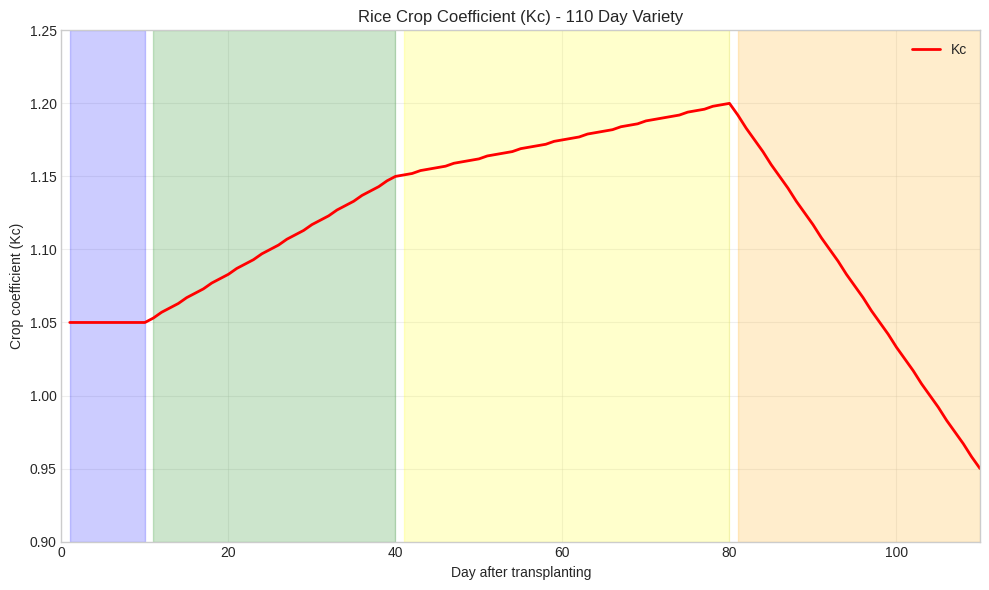


📈 Verification plot saved as 'rice_kc_110_verification.png'

=== FILE CREATION COMPLETE ===
🎯 The file 'rice_kc_110.xlsx' is now ready for use in your CWR calculation
📁 File contains 110 rows with Day and Kc columns
🔄 You can now run the CWR calculation cell without errors


In [ ]:
import pandas as pd
import numpy as np

print("=== CREATING RICE KC 110-DAY FILE FROM PLOT DATA ===")

# Create Kc values based on your plot
# The red line shows a typical rice Kc curve:
# - Initial stage (days 1-10): Kc ≈ 1.05
# - Development stage (days 11-40): Kc increases from 1.05 to 1.15
# - Mid-season stage (days 41-80): Kc ≈ 1.2 (peak)
# - Late season stage (days 81-110): Kc decreases from 1.2 to 0.95

days = list(range(1, 111))  # 110 days
kc_values = []

for day in days:
    if day <= 10:
        # Initial stage - constant low value
        kc = 1.05
    elif day <= 40:
        # Development stage - linear increase
        kc = 1.05 + (1.15 - 1.05) * (day - 10) / (40 - 10)
    elif day <= 80:
        # Mid-season stage - peak value with slight increase
        kc = 1.15 + (1.2 - 1.15) * (day - 40) / (80 - 40)
    else:
        # Late season stage - linear decrease
        kc = 1.2 + (0.95 - 1.2) * (day - 80) / (110 - 80)

    kc_values.append(round(kc, 3))

# Create DataFrame
rice_kc_df = pd.DataFrame({
    'Day': days,
    'Kc': kc_values
})

# Save as Excel file
excel_filename = 'rice_kc_110.xlsx'
rice_kc_df.to_excel(excel_filename, index=False)

print(f"✅ Created {excel_filename} with 110 days of Kc values")
print(f"📊 Kc range: {min(kc_values):.3f} to {max(kc_values):.3f}")

# Display first 10 and last 10 rows
print(f"\n📋 First 10 days:")
print(rice_kc_df.head(10).to_string(index=False))

print(f"\n📋 Last 10 days:")
print(rice_kc_df.tail(10).to_string(index=False))

# Show key stages
print(f"\n📋 Key growth stages:")
print(f"Initial (Day 1-10): Kc = {rice_kc_df.iloc[0]['Kc']:.3f} to {rice_kc_df.iloc[9]['Kc']:.3f}")
print(f"Development (Day 11-40): Kc = {rice_kc_df.iloc[10]['Kc']:.3f} to {rice_kc_df.iloc[39]['Kc']:.3f}")
print(f"Mid-season (Day 41-80): Kc = {rice_kc_df.iloc[40]['Kc']:.3f} to {rice_kc_df.iloc[79]['Kc']:.3f}")
print(f"Late season (Day 81-110): Kc = {rice_kc_df.iloc[80]['Kc']:.3f} to {rice_kc_df.iloc[109]['Kc']:.3f}")

# Optional: Create a plot to verify it matches your chart
try:
    import matplotlib.pyplot as plt

    plt.figure(figsize=(10, 6))
    plt.plot(rice_kc_df['Day'], rice_kc_df['Kc'], 'r-', linewidth=2, label='Kc')
    plt.xlabel('Day after transplanting')
    plt.ylabel('Crop coefficient (Kc)')
    plt.title('Rice Crop Coefficient (Kc) - 110 Day Variety')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.ylim(0.9, 1.25)
    plt.xlim(0, 110)

    # Add stage annotations
    plt.axvspan(1, 10, alpha=0.2, color='blue', label='Initial')
    plt.axvspan(11, 40, alpha=0.2, color='green', label='Development')
    plt.axvspan(41, 80, alpha=0.2, color='yellow', label='Mid-season')
    plt.axvspan(81, 110, alpha=0.2, color='orange', label='Late season')

    plt.tight_layout()
    plt.savefig('rice_kc_110_verification.png', dpi=150, bbox_inches='tight')
    plt.show()

    print(f"\n📈 Verification plot saved as 'rice_kc_110_verification.png'")

except ImportError:
    print(f"\n📈 Matplotlib not available - plot skipped")

print(f"\n=== FILE CREATION COMPLETE ===")
print(f"🎯 The file 'rice_kc_110.xlsx' is now ready for use in your CWR calculation")
print(f"📁 File contains 110 rows with Day and Kc columns")
print(f"🔄 You can now run the CWR calculation cell without errors")

In [ ]:
import pandas as pd
import numpy as np

# read the data file
df = pd.read_csv('klambu_daily_ET0_with_startdates.csv')

# create a new column that has find the 0 target index to be used later
df['target'] = (df['DOY'] - df['startDate']).abs()

# grab the index of 0-crossing target value and convert to an array
idx = df.index[df['target'] == 0].to_numpy()

# add 110 data points to each element in the array by expansion and convert to pandas index
# this is done to account for 110-day rice common in Indonesia
inc = 1
ninc = 110
newidx = pd.Index(np.add.outer(idx, inc * np.arange(ninc)).ravel())

# write to a new df with only selected rows
newdf = df.iloc[newidx]
#print(newdf)
#newdf.to_csv('tt.csv')

# now read rice Kc (110 day version)
kc = pd.read_excel('rice_kc_110.xlsx')

# repeat Kc values 749 times using pd.concat and list comprehension
# 749 is the number of tertirary blocks in Klambu - change if needed
n = 749  # Number of tertiary blocks or repetations
kc_blocks = pd.concat([kc] * n, ignore_index=True)
#print(kc_blocks)
#kc_blocks.to_csv('kc_blocks.csv')

# make sure the two dataframes match in length
print('ET0 data length =', len(newdf))
print('Kc data length =', len(kc_blocks))

# now combine two dataframes horizontally
combined = pd.concat([newdf.reset_index(drop=True), kc_blocks.reset_index(drop=True)], axis=1)
#print(combined)

# calculate crop water requirements
# note that the ET0 dataframe has been adjusted for differential start times as above
combined['CWR'] = combined['ET0'] * combined['Kc']
print(combined)
combined.to_csv('cwr.csv')

ET0 data length = 95150
Kc data length = 82390
                        system:index  year  month  day        date  DOY  \
0      20231024_00000000000000000225  2023     10   24  10/24/2023  297   
1      20231025_00000000000000000225  2023     10   25  10/25/2023  298   
2      20231026_00000000000000000225  2023     10   26  10/26/2023  299   
3      20231027_00000000000000000225  2023     10   27  10/27/2023  300   
4      20231028_00000000000000000225  2023     10   28  10/28/2023  301   
...                              ...   ...    ...  ...         ...  ...   
95145  20240223_00000000000000000299  2024      2   23   2/23/2024   54   
95146  20240224_00000000000000000299  2024      2   24   2/24/2024   55   
95147  20240225_00000000000000000299  2024      2   25   2/25/2024   56   
95148  20240226_00000000000000000299  2024      2   26   2/26/2024   57   
95149  20240227_00000000000000000299  2024      2   27   2/27/2024   58   

                            nama  norec        ET0  

In [ ]:
import ee
import math
import random

# Initialize Earth Engine
#ee.Initialize(project='ee-geodeticengineeringundip')

# Load the study area feature collection
klambu = ee.FeatureCollection("projects/ee-ozdogan05/assets/indonesia/klambu_nonsaluran_tertiary")
box = klambu.geometry().bounds()

###########################################
# PART 1 - BUILD FUNCTIONS TO DO THE WORK
###########################################

def LinearResampling(collection, date_attribute, date_interval, region):
    """
    Function to linearly interpolate satellite images

    Args:
        collection: collection to interpolate
        date_attribute: the property attribute that defines the date of image acquisition
        date_interval: interval to interpolate in days
        region: AOI
    """
    # Setup timestep
    bandNames = collection.first().bandNames()
    minDate = ee.Date(ee.Number(collection.first().get(date_attribute)))

    def add_timestep(image):
        return (image.set("timestep",
                         ee.Number(ee.Date(ee.Number(image.get(date_attribute)))
                                 .difference(minDate, "day")).float())
                     .copyProperties(image)
                     .set('system:time_start', image.get('system:time_start')))

    collection = collection.map(add_timestep).sort("timestep")

    # Calculate date limit for resampling range
    dateLimit = (ee.Number(ee.Image(collection.toList(1, collection.size().add(-1)).get(0))
                          .get("timestep")).ceil().int())

    # Calculate date indexes for time interval
    def add_constant(image):
        constant = (ee.Image.constant(ee.Number(image.get("timestep")).float())
                      .float()
                      .mask(ee.Image(image).mask().float().select([0]))
                      .set("timestep", image.get("timestep"))
                      .rename("timestep"))
        return (image.addBands(constant)
                     .copyProperties(image)
                     .set('system:time_start', image.get('system:time_start')))

    indexes = collection.map(add_constant).sort("timestep", False)

    dateSequence = ee.List.sequence(0, dateLimit.add(-1), date_interval)

    def mosaic_upper_iteration(dateVal, acc):
        acc = ee.List(acc)
        latest_image = (indexes.filter(ee.Filter.gte('timestep', ee.Number(dateVal).float()))
                             .mosaic())
        return acc.add(latest_image)

    mosaicUpperVal = ee.List(dateSequence.iterate(mosaic_upper_iteration, ee.List([])))

    def calc_date_diff(dateVal):
        idx = ee.Number(dateVal).float().divide(date_interval).round().int()
        return (ee.Image(mosaicUpperVal.get(idx))
                  .subtract(ee.Image(mosaicUpperVal.get(idx.subtract(1))))
                  .neq(0))

    dateDiff = dateSequence.slice(1, dateSequence.size()).map(calc_date_diff)
    dateDiff = ee.List([dateDiff.get(0)]).cat(dateDiff)

    def mosaic_lower_iteration(dateVal, acc):
        idx = ee.Number(dateVal).float().divide(date_interval).round().int()
        acc = ee.List(acc)
        min_img = ee.Image(acc.get(0))
        list_imgs = ee.List(acc.get(1))
        diff = ee.Image(dateDiff.get(idx))
        new_img = ee.Image(mosaicUpperVal.get(idx.subtract(1)))
        min_img = min_img.where(diff, new_img)
        list_imgs = list_imgs.add(min_img)
        return [min_img, list_imgs]

    mosaicLowerVal = ee.List(ee.List(dateSequence.iterate(
        mosaic_lower_iteration,
        ee.List([ee.Image(mosaicUpperVal.get(0)), []]))).get(1))

    def interpolation_iteration(dateVal, acc):
        acc = ee.List(acc)
        idx = ee.Number(dateVal).float().divide(date_interval).round().int()
        minFrame = ee.Image(mosaicLowerVal.get(idx)).float()
        maxFrame = ee.Image(mosaicUpperVal.get(idx)).float()

        minDate_img = minFrame.select("timestep")
        maxDate_img = maxFrame.select("timestep")
        minVal = minFrame.select(bandNames)
        maxVal = maxFrame.select(bandNames)
        constantIdx = (ee.Image.constant(ee.Number(dateVal)).float()
                         .clip(region).rename("timestep"))

        out = minVal.add((maxVal.subtract(minVal))
                        .multiply(constantIdx.subtract(minDate_img))
                        .divide(maxDate_img.subtract(minDate_img)))

        # Replace masked value with previous interpolated image
        out = ee.Algorithms.If(
            acc.size().gt(0),
            out.unmask(0).clip(region).where(out.mask().Not(), acc.get(acc.size().add(-1))),
            out
        )
        return acc.add(out)

    interpolated = ee.List(dateSequence.iterate(interpolation_iteration, ee.List([])))
    return ee.ImageCollection(interpolated)

# Landsat Collection 2 data functions
def getQABits(image, start, end, newName):
    """
    A function that returns an image containing just the specified QA bits.
    """
    # Compute the bits we need to extract
    pattern = 0
    for i in range(start, end + 1):
        pattern += int(math.pow(2, i))

    # Return a single band image of the extracted QA bits
    return (image.select([0], [newName])
                 .bitwiseAnd(pattern)
                 .rightShift(start))

def maskClouds(image):
    """Function to mask out clouds in Landsat collection 2 images"""
    pixelQA = image.select('QA_PIXEL')
    cloud = getQABits(pixelQA, 3, 3, 'cloud')
    cldShadow = getQABits(pixelQA, 4, 4, 'cloud_shadow')
    return (image.updateMask(cloud.eq(0))
                 .updateMask(cldShadow.eq(0))
                 .copyProperties(image)
                 .set('system:time_start', image.get('system:time_start')))

def addGCI(image):
    """Function to add GCI"""
    gci = image.select('nir').divide(image.select('green')).rename('GCI')
    return (image.addBands(gci)
                 .copyProperties(image)
                 .set('system:time_start', image.get('system:time_start')))

def addNDVI(image):
    """Function to add NDVI"""
    ndvi = image.normalizedDifference(['nir', 'red']).rename('NDVI')
    return (image.addBands(ndvi)
                 .copyProperties(image)
                 .set('system:time_start', image.get('system:time_start')))

def addAlbedo(image):
    """Function to add Albedo"""
    albedo = (image.select('blue').multiply(0.254)
                   .add(image.select('green').multiply(0.149))
                   .add(image.select('red').multiply(0.147))
                   .add(image.select('nir').multiply(0.311))
                   .add(image.select('swir1').multiply(0.103))
                   .add(image.select('swir2').multiply(0.036))
                   .rename('albedo'))
    return (image.addBands(albedo)
                 .copyProperties(image)
                 .set('system:time_start', image.get('system:time_start')))

def addSAVI(image):
    """Function to add SAVI"""
    savi = image.expression(
        '((nir - red) / (nir + red + 0.5)) * 1.5',
        {
            'red': image.select('red'),
            'nir': image.select('nir'),
        }).rename('SAVI')
    savi = savi.updateMask(savi.gte(0).Or(savi.lte(1)))
    return (image.addBands(savi)
                 .copyProperties(image)
                 .set('system:time_start', image.get('system:time_start')))

def scaleC2(image):
    """Scale Landsat collection 2 images"""
    blue = image.select('blue').multiply(0.0000275).add(-0.2).rename('blue')
    green = image.select('green').multiply(0.0000275).add(-0.2).rename('green')
    red = image.select('red').multiply(0.0000275).add(-0.2).rename('red')
    nir = image.select('nir').multiply(0.0000275).add(-0.2).rename('nir')
    swir1 = image.select('swir1').multiply(0.0000275).add(-0.2).rename('swir1')
    swir2 = image.select('swir2').multiply(0.0000275).add(-0.2).rename('swir2')
    lst = image.select('LST').multiply(0.00341802).add(149).rename('LST')

    return (blue.updateMask(blue.gt(0).Or(blue.lt(1)))
                .addBands(green.updateMask(green.gte(0).Or(green.lte(1))))
                .addBands(red.updateMask(red.gte(0).Or(red.lte(1))))
                .addBands(nir.updateMask(nir.gte(0).Or(nir.lte(1))))
                .addBands(swir1.updateMask(swir1.gte(0).Or(swir1.lte(1))))
                .addBands(swir2.updateMask(swir2.gte(0).Or(swir2.lte(1))))
                .addBands(lst)
                .copyProperties(image)
                .set('system:time_start', image.get('system:time_start')))

def addDOY(image):
    """Function to return DOY [day of the year]"""
    doy = ee.Number(ee.Date(image.get('system:time_start')).getRelative('day', 'year')).add(1)
    return (image.addBands(ee.Image(doy).rename('DOY'))
                 .copyProperties(image)
                 .set('system:time_start', image.get('system:time_start')))

# Get constants and add them to the collection
elev = ee.Image("USGS/SRTMGL1_003").select('elevation')
slope = ee.Terrain.slope(elev).rename('slope')
wc = (ee.ImageCollection('ESA/WorldCover/v100').first()
        .remap([10, 20, 30, 40, 50, 60, 70, 80, 90], [1, 2, 3, 4, 5, 6, 7, 8, 9])
        .rename('landcover'))
clim = (ee.Image('WORLDCLIM/V1/BIO')
          .select(['bio01', 'bio12'], ['temp', 'precip']))

def addConstants(image):
    """Function to add constants to the collection"""
    return (image.addBands(elev)
                 .addBands(slope)
                 .addBands(wc)
                 .addBands(clim.select('temp').multiply(0.1))
                 .addBands(clim.select('precip'))
                 .copyProperties(image)
                 .set('system:time_start', image.get('system:time_start')))

def addClim(image):
    """Function to add climate data from ERA5-Land daily to satellite collection"""
    imageDateStamp = ee.Date(ee.Date(image.get('system:time_start')).format('YYYY-MM-dd'))
    climData = (ee.ImageCollection(ee.List(image.get('ERA5')))
                  .filterDate(imageDateStamp, imageDateStamp.advance(1, 'day')))

    tmin = climData.select('temperature_2m_min').first().subtract(273.15).rename('Tmin')
    tmax = climData.select('temperature_2m_max').first().subtract(273.15).rename('Tmax')
    tmean = climData.select('temperature_2m').first().subtract(273.15).rename('Tmean')
    rain = climData.select('total_precipitation_sum').first().multiply(1000).rename('rain')
    tdew = climData.select('dewpoint_temperature_2m').first().subtract(273.15).rename('Tdew')

    # Actual vapor pressure in kPa with tdew in C
    ea = tdew.expression(
        '6.11 * 10 ** ((7.5 * tdew) / (237.3 + tdew))',
        {'tdew': tdew}).divide(10.0).rename('ea')

    # Saturation Vapor Pressure in kPa with air temperature in C
    es = tmean.expression(
        '0.6108 * exp(17.27 * tmean / (tmean + 237.3))',
        {'tmean': tmean}).rename('es')

    # VPD
    vpd = es.subtract(ea).rename('VPD')  # in kPa

    # Solar radiation
    rad = (climData.select('surface_solar_radiation_downwards_sum').first()
                   .divide(86400)
                   .rename('rad'))  # w/m2

    # Wind speed [m/s]
    u = climData.select('u_component_of_wind_10m').first().pow(2)
    v = climData.select('v_component_of_wind_10m').first().pow(2)
    ws = u.add(v).sqrt().rename('windSpeed').rename('wind')  # m/s

    # Downward SW net radiation in MJ/m2/day
    SWnet = (climData.select('surface_net_solar_radiation_sum').first()
                     .divide(1000000)
                     .rename('SWnet'))

    # Downward LW net radiation in MJ/m2/day
    LWnet = (climData.select('surface_net_thermal_radiation_sum').first()
                     .divide(1000000)
                     .rename('LWnet'))

    # Net solar radiation in MJ/m2/day
    Rnet = SWnet.subtract(LWnet).rename('Rnet')

    # Slope of the Saturation Vapor Pressure-Temperature Curve (Δ)
    slope_vapor = tmean.expression(
        '(4090 * (0.6108 * exp((17.27 * tmean)/(tmean + 237.3)))) / pow((tmean + 237.3), 2)',
        {'tmean': tmean}).rename('slope')

    # Psychrometric Constant in kPa/C - pressure in kPa
    psy = (climData.select('surface_pressure').first()
                   .multiply(0.001)
                   .multiply(0.000665)
                   .rename('psy'))

    # Daily reference ET in mm/day [G = 0]
    pet = tmean.expression(
        '(0.408 * slope * (Rnet - 0) + (psy * (900 / (tmean + 273))) * ws * (es - ea)) / (slope + psy * (0.34 * ws + 1))',
        {
            'slope': slope_vapor,
            'Rnet': Rnet,
            'psy': psy,
            'tmean': tmean,
            'ws': ws,
            'es': es,
            'ea': ea
        }).rename('PET')  # mm/day

    return (image.addBands(tmin)
                 .addBands(tmax)
                 .addBands(tmean)
                 .addBands(rain)
                 .addBands(tdew)
                 .addBands(ea)
                 .addBands(vpd)
                 .addBands(rad)
                 .addBands(pet)
                 .set({
                     'system:time_start': image.get('system:time_start'),
                     'system:time_end': image.get('system:time_end')
                 }))

def addDates(image):
    """Function to add dates"""
    yr = ee.Date(image.get('system:time_start')).get('year')
    mn = ee.Date(image.get('system:time_start')).get('month')
    dy = ee.Date(image.get('system:time_start')).get('day')
    return (image.addBands(ee.Image(yr).rename('year'))
                 .addBands(ee.Image(mn).rename('month'))
                 .addBands(ee.Image(dy).rename('day'))
                 .copyProperties(image)
                 .set('system:time_start', image.get('system:time_start')))

def applyModel(image, model):
    """Function to apply a trained random forest regression model"""
    output = image.classify(model).rename('ETa')
    return (image.addBands(output)
                 .copyProperties(image)
                 .set('system:time_start', image.get('system:time_start')))

######################################################
# PART 2 - GET SATELLITE DATA AND DO PREPROCESSING
#####################################################

# Random integer for reproducibility
randInt = ee.Number(random.random()).multiply(366).floor().add(1)

year = ee.Number(2023)
sdate = ee.Date.fromYMD(year, 10, 1).advance(-10, 'day')  # extra 10 days before
edate = sdate.advance(6, 'month').advance(20, 'day')  # extra 10 days after
print('Start date:', sdate.getInfo())
print('End date:', edate.getInfo())

# Landsat 9 collection 2
L9coll = (ee.ImageCollection('LANDSAT/LC09/C02/T1_L2')
            .filterBounds(box)
            .filterDate(sdate, edate)
            .map(maskClouds)
            .select(['SR_B2', 'SR_B3', 'SR_B4', 'SR_B5', 'SR_B6', 'SR_B7', 'ST_B10'],
                   ['blue', 'green', 'red', 'nir', 'swir1', 'swir2', 'LST'])
            .map(scaleC2))

# Landsat 8 collection 2
L8coll = (ee.ImageCollection('LANDSAT/LC08/C02/T1_L2')
            .filterBounds(box)
            .filterDate(sdate, edate)
            .map(maskClouds)
            .select(['SR_B2', 'SR_B3', 'SR_B4', 'SR_B5', 'SR_B6', 'SR_B7', 'ST_B10'],
                   ['blue', 'green', 'red', 'nir', 'swir1', 'swir2', 'LST'])
            .map(scaleC2))

# Landsat 7 collection 2
L7coll = (ee.ImageCollection('LANDSAT/LE07/C02/T1_L2')
            .filterBounds(box)
            .filterDate(sdate, edate)
            .map(maskClouds)
            .select(['SR_B1', 'SR_B2', 'SR_B3', 'SR_B4', 'SR_B5', 'SR_B7', 'ST_B6'],
                   ['blue', 'green', 'red', 'nir', 'swir1', 'swir2', 'LST'])
            .map(scaleC2))

# Landsat 5 collection 2
L5coll = (ee.ImageCollection('LANDSAT/LT05/C02/T1_L2')
            .filterBounds(box)
            .filterDate(sdate, edate)
            .map(maskClouds)
            .select(['SR_B1', 'SR_B2', 'SR_B3', 'SR_B4', 'SR_B5', 'SR_B7', 'ST_B6'],
                   ['blue', 'green', 'red', 'nir', 'swir1', 'swir2', 'LST'])
            .map(scaleC2))

# Merge Landsat collections and sort by time
coll = (ee.ImageCollection(L9coll.merge(L8coll).merge(L7coll).merge(L5coll))
          .sort('system:time_start', True)
          .map(addNDVI)
          .map(addSAVI)
          .map(addAlbedo)
          .map(addConstants))

print("Landsat collection created")

#######################################################################################################
# PART 3 - LINEARLY INTERPOLATE LANDSAT DATA - PRODUCES REGULAR INTERVAL DATA
#######################################################################################################

# Set the resampling window in days
resamplingWindow = ee.Number(1)

print("Starting linear interpolation...")

# Create an interpolated collection and make it a list
resampled = LinearResampling(coll, "DATE_ACQUIRED", resamplingWindow, box).toList(500)

# Grab the first date of the original collection
collStartDate = ee.Image(coll.first()).get('system:time_start')

# Add dates [this is done because the dates in the resampled collection are missing]
collLength = ee.List.sequence(0, ee.Number(resampled.size()).subtract(1))

def add_dates_to_resampled(day):
    thisDay = ee.Number(day)
    withDate = (ee.Image(resampled.get(thisDay))
                  .set('system:time_start',
                       ee.Date(collStartDate).advance(thisDay.multiply(resamplingWindow), 'day').millis()))
    return withDate

resampleCollWithDates = (ee.ImageCollection(collLength.map(add_dates_to_resampled))
                           .map(addDOY))

print("Linear interpolation completed")

#######################################################################################################
# PART 4 - ADD CLIMATE DATA FROM ERA5 TO INTERPOLATED SATELLITE DATA THROUGH A JOIN
#######################################################################################################

print("Loading ERA5 climate data...")

# Get ERA5-Land daily data
era5 = (ee.ImageCollection("ECMWF/ERA5_LAND/DAILY_AGGR")
          .select([
              'temperature_2m',
              'temperature_2m_min',
              'temperature_2m_max',
              'total_precipitation_sum',
              'dewpoint_temperature_2m',
              'surface_solar_radiation_downwards_sum',
              'u_component_of_wind_10m',
              'v_component_of_wind_10m',
              'surface_pressure',
              'surface_net_solar_radiation_sum',
              'surface_net_thermal_radiation_sum',
          ]))

# Define an allowable time difference: one day in milliseconds
DaysMillis = 1 * 24 * 60 * 60 * 1000

# Create a time filter to define a match as overlapping timestamps
timeFilter = ee.Filter.Or(
    ee.Filter.maxDifference(**{
        'difference': DaysMillis,
        'leftField': 'system:time_start',
        'rightField': 'system:time_end'
    }),
    ee.Filter.maxDifference(**{
        'difference': DaysMillis,
        'leftField': 'system:time_end',
        'rightField': 'system:time_start'
    })
)

# Define the join
saveAllJoin = ee.Join.saveAll(**{
    'matchesKey': 'ERA5',
    'ordering': 'system:time_start',
    'ascending': True
})

# Apply the join and add climate variables as bands
landsatClim = ee.ImageCollection(saveAllJoin.apply(resampleCollWithDates, era5, timeFilter)).map(addClim)

print("Climate data joined with satellite data")

#######################################################################################################
# PART 5 - TRAIN AND APPLY A RANDOM-FOREST REGRESSION MODEL TO ESTIMATE ET
#######################################################################################################

print("Loading training data and building model...")

# Get training data
training = ee.FeatureCollection("projects/ee-ozdogan05/assets/et_training_v4_2016_2023_sampled")

# Randomly sample 20 percent of the data
training = (training.randomColumn('rand', randInt)
                   .filter(ee.Filter.lt('rand', 0.2)))

# Build a random-forest regression model with 150 trees
model = (ee.Classifier.smileRandomForest(150)
           .setOutputMode('REGRESSION')
           .train(**{
               'features': training,
               'classProperty': 'ETa',
               'inputProperties': ['DOY', 'Tmin', 'Tmax', 'Tmean', 'rain', 'ea',
                                 'VPD', 'rad', 'PET', 'temp', 'precip', 'landcover', 'LST', 'NDVI',
                                 'SAVI', 'red', 'swir1', 'swir2', 'albedo', 'elevation', 'slope']
           }))

print("Model trained, applying to satellite data...")

# Apply the trained model to produce actual ET estimates
def apply_model_wrapper(image):
    return applyModel(image, model)

result = (landsatClim.map(apply_model_wrapper)
                    .map(addDates))

print("ETa estimation completed")

# Extract daily ETa for each tertiary block
def reduce_regions(image):
    return image.reduceRegions(**{
        'collection': klambu,
        'reducer': ee.Reducer.mean(),
        'scale': 250
    })

out = (result.filterDate('2023-10-01', '2024-04-01')  # filter for exact dates needed
             .select(['year', 'month', 'day', 'DOY','ETa'])
             .map(reduce_regions)
             .flatten())  # flatten is required to go from 2d collection to 1d collection

print("Starting export...")

# Export as a CSV file
task = ee.batch.Export.table.toDrive(**{
    'collection': out,
    'description': 'klambu_daily_ETa',
    'fileFormat': 'CSV',
    'folder': '0000_PUPR',
    'selectors': ['system:index', 'nama', 'norec', 'year', 'month', 'day', 'DOY','ETa']
})
task.start()

# Create variable for next use
klambu_eta = out

print("="*50)
print("EXPORT TASK STARTED SUCCESSFULLY")
print("="*50)
print("Daily ETa data will be saved as 'klambu_daily_ETa.csv' in Google Drive")
print("Data available as variable 'klambu_eta' for next cell")
print("\nThis dataset contains:")
print("- Daily actual evapotranspiration estimates")
print("- From October 2023 to April 2024")
print("- For each tertiary irrigation block")
print("- Estimated using machine learning with Landsat + ERA5 data")
print("\nCheck your Google Earth Engine Tasks tab to monitor progress.")

Start date: {'type': 'Date', 'value': 1695254400000}
End date: {'type': 'Date', 'value': 1712707200000}
Landsat collection created
Starting linear interpolation...
Linear interpolation completed
Loading ERA5 climate data...
Climate data joined with satellite data
Loading training data and building model...
Model trained, applying to satellite data...
ETa estimation completed
Starting export...
EXPORT TASK STARTED SUCCESSFULLY
Daily ETa data will be saved as 'klambu_daily_ETa.csv' in Google Drive
Data available as variable 'klambu_eta' for next cell

This dataset contains:
- Daily actual evapotranspiration estimates
- From October 2023 to April 2024
- For each tertiary irrigation block
- Estimated using machine learning with Landsat + ERA5 data

Check your Google Earth Engine Tasks tab to monitor progress.


In [ ]:
import pandas as pd

# the purpose of this script is to join daily ETa file
# with the day of transplating file to be used in
# estimating rice crop water requirements

# read ETa file
df1 = pd.read_csv('/content/drive/MyDrive/0000_PUPR/klambu_daily_ETa.csv')

# read start date file and adjust coilumns
df2 = pd.read_excel('klambu_new_dates.xlsx')
df2['startDate'] = df2['NDWImaxDate'].astype(int)
df2['endDate'] = df2['NDVImaxDate'].astype(int)


# using merge function by setting how='outer'
output = pd.merge(df1, df2[['norec','startDate','endDate','diff']], on=['norec'], how='outer')

output.to_csv('klambu_daily_ETa_with_startdates.csv', sep=',')

In [ ]:
import pandas as pd

# Read the CSV file into a pandas DataFrame
try:
    df_eta_dates = pd.read_csv('klambu_daily_ETa_with_startdates.csv')
    print("Successfully read klambu_daily_ETa_with_startdates.csv")

    # Display the first 10 records
    print("\nFirst 10 records of klambu_daily_ETa_with_startdates.csv:")
    print(df_eta_dates.head(10))

except FileNotFoundError:
    print("Error: klambu_daily_ETa_with_startdates.csv not found.")
    print("Please make sure the file exists in the current directory.")
except Exception as e:
    print(f"An error occurred while reading the file: {e}")

Successfully read klambu_daily_ETa_with_startdates.csv

First 10 records of klambu_daily_ETa_with_startdates.csv:
   Unnamed: 0             system:index                     nama  norec  \
0           0   8_00000000000000000225  Petak Tersier B Wi 1 ka    225   
1           1   9_00000000000000000225  Petak Tersier B Wi 1 ka    225   
2           2  10_00000000000000000225  Petak Tersier B Wi 1 ka    225   
3           3  11_00000000000000000225  Petak Tersier B Wi 1 ka    225   
4           4  12_00000000000000000225  Petak Tersier B Wi 1 ka    225   
5           5  13_00000000000000000225  Petak Tersier B Wi 1 ka    225   
6           6  14_00000000000000000225  Petak Tersier B Wi 1 ka    225   
7           7  15_00000000000000000225  Petak Tersier B Wi 1 ka    225   
8           8  16_00000000000000000225  Petak Tersier B Wi 1 ka    225   
9           9  17_00000000000000000225  Petak Tersier B Wi 1 ka    225   

     year  month   day    DOY       ETa  startDate  endDate  diff  
0  

In [ ]:
import pandas as pd
import numpy as np

# read the data file
df = pd.read_csv('klambu_daily_ETa_with_startdates.csv')

# create a new column that has find the 0 target index to be used later
df['target'] = (df['DOY'] - df['startDate']).abs()

# grab the index of 0-crossing target value and convert to an array
idx = df.index[df['target'] == 0].to_numpy()

# add 110 data points to each element in the array by expansion and convert to pandas index
# this is done to account for 110-day rice common in Indonesia
inc = 1
ninc = 110
newidx = pd.Index(np.add.outer(idx, inc * np.arange(ninc)).ravel())

# write to a new df with only selected rows
newdf = df.iloc[newidx]

# now read the CWR data that has been time adjusted in previous steps
# NOTE: NEED CONFIRMATION OF FILE klambu_daily_cwr.xlsx
cwr = pd.read_csv('cwr.csv')

# join the two dataframes based on dates and record number
# note that this inner join is done to make sure if any missing record number
# or tertiary block is removed from the analysis due to missing satellite date
# when calculating ETa
output = pd.merge(newdf, cwr, on=['norec','year','month','day'], how='inner')

# Check what columns are actually available after the merge
print("Available columns after merge:")
print(output.columns.tolist())

# now calculate the satisfaction index
# the 1.2 empirical correction factor is applied because
# it is observed that ETa tends to underestimate actual ET in humid areas
# can be adjusted if necessary
output['satIndex'] = (1.2 * output['ETa']) / output['CWR']

# finally suppress SI values > 1 or 100%
# this happens because of the differences between how
# ET0 and ETa are calculated
output.loc[output['satIndex'] > 1, 'satIndex'] = 1.0

# Dynamically select columns based on what's actually available
columns_to_export = []
column_mapping = {
    'nama': ['nama', 'nama_x', 'nama_y'],
    'norec': ['norec'],
    'year': ['year'],
    'month': ['month'],
    'day': ['day'],
    'date': ['date', 'date_x', 'date_y'],
    'DOY': ['DOY', 'DOY_x', 'DOY_y'],
    'startDate': ['startDate', 'startDate_x', 'startDate_y'],
    'endDate': ['endDate', 'endDate_x', 'endDate_y'],
    'target': ['target', 'target_x', 'target_y'],
    'ET0': ['ET0'],
    'Kc': ['Kc'],
    'CWR': ['CWR'],
    'ETa': ['ETa'],
    'satIndex': ['satIndex']
}

# Find the actual column names
final_columns = []
for desired_col, possible_names in column_mapping.items():
    found = False
    for possible_name in possible_names:
        if possible_name in output.columns:
            final_columns.append(possible_name)
            found = True
            break
    if not found:
        print(f"Warning: Could not find column for {desired_col}")

print(f"\nColumns to export: {final_columns}")

# Export the data with the actual column names
output[final_columns].to_csv('klambu_daily_SI.csv', index=False)

print(f"Successfully exported {len(output)} rows to klambu_daily_SI.csv")
print(f"Exported columns: {final_columns}")

Available columns after merge:
['Unnamed: 0_x', 'system:index_x', 'nama_x', 'norec', 'year', 'month', 'day', 'DOY_x', 'ETa', 'startDate_x', 'endDate_x', 'diff_x', 'target_x', 'Unnamed: 0_y', 'system:index_y', 'date', 'DOY_y', 'nama_y', 'ET0', 'startDate_y', 'endDate_y', 'diff_y', 'target_y', 'Day', 'Kc', 'CWR']

Columns to export: ['nama_x', 'norec', 'year', 'month', 'day', 'date', 'DOY_x', 'startDate_x', 'endDate_x', 'target_x', 'ET0', 'Kc', 'CWR', 'ETa', 'satIndex']
Successfully exported 89145 rows to klambu_daily_SI.csv
Exported columns: ['nama_x', 'norec', 'year', 'month', 'day', 'date', 'DOY_x', 'startDate_x', 'endDate_x', 'target_x', 'ET0', 'Kc', 'CWR', 'ETa', 'satIndex']


In [ ]:
import pandas as pd
import numpy as np

print("=== AGGREGATING DAILY SI TO WEEKLY SI ===")

# Read the daily SI data
try:
    df = pd.read_csv('klambu_daily_SI.csv')
    print(f"✓ Loaded daily SI data: {df.shape}")
    print(f"✓ Columns: {list(df.columns)}")
except FileNotFoundError:
    print("✗ klambu_daily_SI.csv not found. Checking for alternative files...")
    # Try alternative file names
    alternative_files = [
        'klambu_daily_SI.xlsx',
        'klambu_daily_ETa_with_startdates.csv',
        'cwr.csv'
    ]

    df = None
    for file_path in alternative_files:
        try:
            if file_path.endswith('.xlsx'):
                df = pd.read_excel(file_path)
            else:
                df = pd.read_csv(file_path)
            print(f"✓ Loaded alternative file: {file_path} ({df.shape})")
            break
        except:
            continue

    if df is None:
        raise FileNotFoundError("No suitable daily SI data file found")

# Display sample of original data
print(f"\n📊 Sample of original data:")
print(df.head(3))

# Data preprocessing
print(f"\n🔧 Data preprocessing...")

# Ensure required columns exist
required_columns = ['norec', 'satIndex']
missing_cols = [col for col in required_columns if col not in df.columns]
if missing_cols:
    print(f"✗ Missing required columns: {missing_cols}")
    print(f"Available columns: {list(df.columns)}")
    raise ValueError(f"Missing required columns: {missing_cols}")

# Create date column if it doesn't exist or fix existing one
if 'date' not in df.columns:
    # Try to create date from year, month, day columns
    if all(col in df.columns for col in ['year', 'month', 'day']):
        df['date'] = pd.to_datetime(df[['year', 'month', 'day']])
        print("✓ Created date column from year/month/day")
    else:
        # Create sequential dates starting from a reference date
        start_date = pd.to_datetime('2023-10-01')
        df['date'] = start_date + pd.to_timedelta(df.index, unit='D')
        print("✓ Created sequential date column")
else:
    # Convert existing date column to datetime
    df['date'] = pd.to_datetime(df['date'], errors='coerce')
    print("✓ Converted existing date column to datetime")

# Create date_new column (formatted as MM/DD/YYYY)
df['date_new'] = df['date'].dt.strftime('%m/%d/%Y')
print("✓ Created date_new column with MM/DD/YYYY format")

# Create ETa_adjusted column (ETa * 1.2 empirical correction factor)
if 'ETa' in df.columns:
    df['ETa_adjusted'] = df['ETa'] * 1.2
    print("✓ Created ETa_adjusted column (ETa * 1.2)")
else:
    # If ETa doesn't exist, try to back-calculate from satIndex and CWR
    if 'satIndex' in df.columns and 'CWR' in df.columns:
        # Since satIndex = (1.2 * ETa) / CWR, then ETa = (satIndex * CWR) / 1.2
        df['ETa'] = (df['satIndex'] * df['CWR']) / 1.2
        df['ETa_adjusted'] = df['ETa'] * 1.2  # This should equal satIndex * CWR
        print("✓ Back-calculated ETa from satIndex and CWR, then created ETa_adjusted")
    else:
        # Create dummy ETa_adjusted if we can't calculate it
        df['ETa_adjusted'] = df['satIndex'] if 'satIndex' in df.columns else 0
        print("⚠️  Created dummy ETa_adjusted column")

# Remove rows with invalid dates
initial_rows = len(df)
df = df.dropna(subset=['date'])
print(f"✓ Removed {initial_rows - len(df)} rows with invalid dates")

# Ensure satIndex is numeric
df['satIndex'] = pd.to_numeric(df['satIndex'], errors='coerce')
df = df.dropna(subset=['satIndex'])
print(f"✓ Ensured satIndex is numeric")

# Ensure norec is numeric
df['norec'] = pd.to_numeric(df['norec'], errors='coerce')
df = df.dropna(subset=['norec'])
print(f"✓ Ensured norec is numeric")

print(f"✓ Final preprocessed data shape: {df.shape}")

# Set date as index for resampling
df_indexed = df.set_index('date').copy()

# Group by norec and resample to weekly averages
print(f"\n📈 Aggregating to weekly averages...")

# Define columns to aggregate (include all numeric columns that make sense to average)
agg_columns = ['satIndex', 'ETa_adjusted']

# Add other columns if they exist
optional_columns = ['ET0', 'Kc', 'CWR', 'ETa', 'year', 'month', 'day', 'DOY']
for col in optional_columns:
    if col in df_indexed.columns:
        agg_columns.append(col)

print(f"✓ Columns to aggregate: {agg_columns}")

# Perform weekly aggregation
weekly_aggregated = df_indexed.groupby('norec')[agg_columns].resample('W').mean()

# Reset index to get norec and date as columns
weekly_df = weekly_aggregated.reset_index()

print(f"✓ Weekly aggregation completed: {weekly_df.shape}")

# Add additional date-related columns
print(f"\n📅 Adding date-related columns...")

weekly_df['year'] = weekly_df['date'].dt.year
weekly_df['month'] = weekly_df['date'].dt.month
weekly_df['day'] = weekly_df['date'].dt.day
weekly_df['week_of_year'] = weekly_df['date'].dt.isocalendar().week
weekly_df['year_week'] = weekly_df['year'].astype(str) + '_W' + weekly_df['week_of_year'].astype(str).str.zfill(2)

# Create date_new for weekly data (week start date in MM/DD/YYYY format)
weekly_df['date_new'] = weekly_df['date'].dt.strftime('%m/%d/%Y')

# Rename date column to week_start_date for clarity
weekly_df = weekly_df.rename(columns={'date': 'week_start_date'})

# Add block information if available
if 'nama' in df.columns:
    # Get the first nama for each norec (assuming it's consistent)
    block_names = df.groupby('norec')['nama'].first().reset_index()
    weekly_df = weekly_df.merge(block_names, on='norec', how='left')
    print("✓ Added block names (nama)")

# Add start/end dates if available
if 'startDate' in df.columns:
    start_dates = df.groupby('norec')['startDate'].first().reset_index()
    weekly_df = weekly_df.merge(start_dates, on='norec', how='left')
    print("✓ Added start dates")

if 'endDate' in df.columns:
    end_dates = df.groupby('norec')['endDate'].first().reset_index()
    weekly_df = weekly_df.merge(end_dates, on='norec', how='left')
    print("✓ Added end dates")

# Round numeric columns to reasonable precision
numeric_columns = weekly_df.select_dtypes(include=[np.number]).columns
for col in numeric_columns:
    if col not in ['norec', 'year', 'month', 'day', 'week_of_year', 'startDate', 'endDate']:
        weekly_df[col] = weekly_df[col].round(4)

# Sort by norec and date
weekly_df = weekly_df.sort_values(['norec', 'week_start_date']).reset_index(drop=True)

# Reorder columns to match expected structure
expected_column_order = [
    'norec', 'nama', 'year', 'month', 'day', 'week_of_year', 'year_week',
    'week_start_date', 'date_new', 'satIndex', 'ETa_adjusted',
    'ET0', 'Kc', 'CWR', 'ETa', 'DOY', 'startDate', 'endDate'
]

# Only include columns that actually exist
final_columns = [col for col in expected_column_order if col in weekly_df.columns]
# Add any remaining columns not in the expected order
remaining_columns = [col for col in weekly_df.columns if col not in final_columns]
final_columns.extend(remaining_columns)

weekly_df = weekly_df[final_columns]

print(f"✓ Final weekly data shape: {weekly_df.shape}")
print(f"✓ Date range: {weekly_df['week_start_date'].min()} to {weekly_df['week_start_date'].max()}")
print(f"✓ Number of unique blocks: {weekly_df['norec'].nunique()}")
print(f"✓ Number of unique weeks: {weekly_df['week_of_year'].nunique()}")

# Display sample of weekly data
print(f"\n📊 Sample of weekly aggregated data:")
print(weekly_df.head(10))

# Save to Excel file
output_filename = 'klambu_weekly_SI.xlsx'
print(f"\n💾 Saving to Excel: {output_filename}")

try:
    weekly_df.to_excel(output_filename, index=False, engine='openpyxl')
    print(f"✅ Successfully saved {len(weekly_df)} rows to {output_filename}")

    # Display file info
    import os
    if os.path.exists(output_filename):
        file_size = os.path.getsize(output_filename)
        print(f"📋 File size: {file_size:,} bytes ({file_size/1024:.1f} KB)")

except Exception as e:
    print(f"✗ Error saving Excel file: {e}")
    # Fallback: save as CSV
    csv_filename = 'klambu_weekly_SI.csv'
    weekly_df.to_csv(csv_filename, index=False)
    print(f"📋 Saved as CSV instead: {csv_filename}")

# Summary statistics
print(f"\n📈 Summary Statistics:")
print(f"   Total records: {len(weekly_df):,}")
print(f"   Date range: {weekly_df['week_start_date'].min().strftime('%Y-%m-%d')} to {weekly_df['week_start_date'].max().strftime('%Y-%m-%d')}")
print(f"   Unique blocks (norec): {weekly_df['norec'].nunique()}")
print(f"   Unique weeks: {weekly_df['week_of_year'].nunique()}")
print(f"   Average satIndex: {weekly_df['satIndex'].mean():.3f}")
print(f"   satIndex range: {weekly_df['satIndex'].min():.3f} - {weekly_df['satIndex'].max():.3f}")
if 'ETa_adjusted' in weekly_df.columns:
    print(f"   Average ETa_adjusted: {weekly_df['ETa_adjusted'].mean():.3f}")
    print(f"   ETa_adjusted range: {weekly_df['ETa_adjusted'].min():.3f} - {weekly_df['ETa_adjusted'].max():.3f}")

# Show column summary
print(f"\n📋 Final column structure:")
for i, col in enumerate(weekly_df.columns, 1):
    dtype = weekly_df[col].dtype
    non_null = weekly_df[col].notna().sum()
    print(f"   {i:2d}. {col:<20} ({dtype}) - {non_null:,} non-null values")

print(f"\n=== WEEKLY AGGREGATION COMPLETE ===")
print(f"Output file: {output_filename}")
print(f"✓ Includes date_new column (MM/DD/YYYY format)")
print(f"✓ Includes ETa_adjusted column (ETa * 1.2)")
print(f"Ready for uniformity and reliability analysis!")

# Create global variable for next steps
klambu_weekly_si_df = weekly_df
print(f"✓ Created variable 'klambu_weekly_si_df' for further processing")

=== AGGREGATING DAILY SI TO WEEKLY SI ===
✓ Loaded daily SI data: (89145, 15)
✓ Columns: ['nama_x', 'norec', 'year', 'month', 'day', 'date', 'DOY_x', 'startDate_x', 'endDate_x', 'target_x', 'ET0', 'Kc', 'CWR', 'ETa', 'satIndex']

📊 Sample of original data:
                    nama_x  norec    year  month   day        date  DOY_x  \
0  Petak Tersier B Wi 1 ka    225  2023.0   10.0  24.0  10/24/2023  297.0   
1  Petak Tersier B Wi 1 ka    225  2023.0   10.0  25.0  10/25/2023  298.0   
2  Petak Tersier B Wi 1 ka    225  2023.0   10.0  26.0  10/26/2023  299.0   

   startDate_x  endDate_x  target_x       ET0    Kc        CWR       ETa  \
0          297          7       0.0  8.011462  1.05   8.412035  3.410871   
1          297          7       1.0  9.518770  1.05   9.994709  3.785983   
2          297          7       2.0  9.558520  1.05  10.036446  3.647574   

   satIndex  
0  0.486570  
1  0.454558  
2  0.436119  

🔧 Data preprocessing...
✓ Converted existing date column to datetime
✓ C

In [ ]:
### CELL 9 : Calculation of Uniformity and Reliability

import pandas as pd
import numpy as np

print("=== UNIFORMITY AND RELIABILITY CALCULATION ===")

# Load the weekly SI data
df = pd.read_excel('klambu_weekly_SI.xlsx')
print(f"✓ Loaded weekly SI data: {df.shape}")

# Ensure we have the required columns
required_cols = ['norec', 'satIndex', 'year_week']
if not all(col in df.columns for col in required_cols):
    print(f"Available columns: {list(df.columns)}")
    # Try alternative column names
    if 'satindex' in df.columns:
        df = df.rename(columns={'satindex': 'satIndex'})
    print("✓ Column mapping complete")

# 1. UNIFORMITY: Spatial standard deviation on weekly basis
print("\n🔄 Calculating WEEKLY UNIFORMITY (spatial variation within each week)...")

weekly_uniformity = df.groupby('year_week').agg({
    'satIndex': ['mean', 'std', 'count'],
    'norec': 'first'  # Just to keep track
}).round(4)

weekly_uniformity.columns = ['mean_SI', 'std_SI', 'block_count', 'sample_norec']
weekly_uniformity = weekly_uniformity.reset_index()

# Calculate weekly uniformity metric (1 - coefficient of variation)
weekly_uniformity['coefficient_variation'] = (weekly_uniformity['std_SI'] / weekly_uniformity['mean_SI']) * 100
weekly_uniformity['uniformity'] = 1 - (weekly_uniformity['std_SI'] / weekly_uniformity['mean_SI'])
weekly_uniformity['uniformity'] = weekly_uniformity['uniformity'].fillna(1).clip(0, 1)  # Handle edge cases
weekly_uniformity['uniformity'] = weekly_uniformity['uniformity'].astype(float)

print(f"✓ Weekly uniformity calculated for {len(weekly_uniformity)} weeks")

# 1B. BLOCK-LEVEL UNIFORMITY: Average uniformity for each block across all weeks
print("\n🔄 Calculating BLOCK-LEVEL UNIFORMITY (for visualization)...")

# For each block, calculate how uniformly it performs compared to other blocks across time
block_uniformity = df.groupby('norec').agg({
    'satIndex': ['mean', 'std', 'count', 'min', 'max'],
    'year_week': 'first'  # Just to keep track
}).round(4)

block_uniformity.columns = ['mean_SI', 'std_SI', 'week_count', 'min_SI', 'max_SI', 'sample_week']
block_uniformity = block_uniformity.reset_index()

# Calculate each block's uniformity (how consistent it is spatially relative to others)
# This measures how much each block deviates from the overall spatial mean
overall_mean_SI = df['satIndex'].mean()
block_uniformity['deviation_from_overall'] = abs(block_uniformity['mean_SI'] - overall_mean_SI)
block_uniformity['uniformity'] = 1 - (block_uniformity['deviation_from_overall'] / overall_mean_SI)
block_uniformity['uniformity'] = block_uniformity['uniformity'].fillna(1).clip(0, 1)  # Handle edge cases
block_uniformity['uniformity'] = block_uniformity['uniformity'].astype(float)

print(f"✓ Block-level uniformity calculated for {len(block_uniformity)} blocks")

# 2. RELIABILITY: Temporal standard deviation for each block
print("\n🔄 Calculating RELIABILITY (temporal variation within each block)...")

reliability = df.groupby('norec').agg({
    'satIndex': ['mean', 'std', 'count', 'min', 'max'],
    'year_week': 'first'  # Just to keep track
}).round(4)

reliability.columns = ['mean_SI', 'std_SI', 'week_count', 'min_SI', 'max_SI', 'sample_week']
reliability = reliability.reset_index()

# Calculate reliability metric (1 - coefficient of variation)
reliability['coefficient_variation'] = (reliability['std_SI'] / reliability['mean_SI']) * 100
reliability['reliability'] = 1 - (reliability['std_SI'] / reliability['mean_SI'])
reliability['reliability'] = reliability['reliability'].fillna(1).clip(0, 1)  # Handle edge cases
reliability['reliability'] = reliability['reliability'].astype(float)

print(f"✓ Reliability calculated for {len(reliability)} blocks")

# 3. SAVE RESULTS
print("\n💾 Saving results...")

# Save weekly uniformity results (original temporal analysis)
weekly_uniformity.to_csv('uniformity_weekly_results.csv', index=False)
print(f"✓ Saved weekly uniformity results: {len(weekly_uniformity)} records")

# Save block-level uniformity results (for visualization)
block_uniformity.to_csv('uniformity_block_results.csv', index=False)
print(f"✓ Saved block-level uniformity results: {len(block_uniformity)} records")

# Save reliability results
reliability.to_csv('reliability_block_results.csv', index=False)
print(f"✓ Saved reliability results: {len(reliability)} records")

# 4. SUMMARY STATISTICS
print(f"\n📊 SUMMARY:")
print(f"Weekly Uniformity (temporal spatial consistency):")
print(f"  Average: {weekly_uniformity['uniformity'].mean():.3f}")
print(f"  Range: {weekly_uniformity['uniformity'].min():.3f} - {weekly_uniformity['uniformity'].max():.3f}")

print(f"Block-level Uniformity (spatial consistency per block):")
print(f"  Average: {block_uniformity['uniformity'].mean():.3f}")
print(f"  Range: {block_uniformity['uniformity'].min():.3f} - {block_uniformity['uniformity'].max():.3f}")

print(f"Reliability (temporal consistency):")
print(f"  Average: {reliability['reliability'].mean():.3f}")
print(f"  Range: {reliability['reliability'].min():.3f} - {reliability['reliability'].max():.3f}")

print(f"\n✅ COMPLETE! Three CSV files created:")
print(f"   1. uniformity_weekly_results.csv - Weekly spatial uniformity analysis")
print(f"   2. uniformity_block_results.csv - Block-level uniformity for visualization")
print(f"   3. reliability_block_results.csv - Block-level temporal reliability")

=== UNIFORMITY AND RELIABILITY CALCULATION ===
✓ Loaded weekly SI data: (10780, 14)

🔄 Calculating WEEKLY UNIFORMITY (spatial variation within each week)...
✓ Weekly uniformity calculated for 26 weeks

🔄 Calculating BLOCK-LEVEL UNIFORMITY (for visualization)...
✓ Block-level uniformity calculated for 653 blocks

🔄 Calculating RELIABILITY (temporal variation within each block)...
✓ Reliability calculated for 653 blocks

💾 Saving results...
✓ Saved weekly uniformity results: 26 records
✓ Saved block-level uniformity results: 653 records
✓ Saved reliability results: 653 records

📊 SUMMARY:
Weekly Uniformity (temporal spatial consistency):
  Average: 0.934
  Range: 0.853 - 1.000
Block-level Uniformity (spatial consistency per block):
  Average: 0.943
  Range: 0.691 - 1.000
Reliability (temporal consistency):
  Average: 0.803
  Range: 0.595 - 0.939

✅ COMPLETE! Three CSV files created:
   1. uniformity_weekly_results.csv - Weekly spatial uniformity analysis
   2. uniformity_block_results.cs

In [ ]:
import geemap
import ee
import pandas as pd

print("=== MAPPING UNIFORMITY AND RELIABILITY RESULTS ===")

# Initialize map
Map = geemap.Map(center=[0, 0], zoom=2)

# Load the study area feature collection (assuming it's already loaded in previous cells)
# klambu = ee.FeatureCollection("projects/ee-ozdogan05/assets/indonesia/klambu_nonsaluran_tertiary")
print("✓ Loaded study area feature collection (klambu)")

# Load the uniformity and reliability results (assuming they are saved as CSV files)
try:
    uniformity_block_df = pd.read_csv('uniformity_block_results.csv')
    reliability_block_df = pd.read_csv('reliability_block_results.csv')
    print("✓ Loaded uniformity and reliability results CSV files")
except FileNotFoundError:
    print("✗ Uniformity or Reliability CSV files not found.")
    print("📋 Please ensure 'uniformity_block_results.csv' and 'reliability_block_results.csv' exist.")
    raise SystemExit("Required CSV files not found - aborting mapping")

# Ensure 'norec' column is integer type for merging
uniformity_block_df['norec'] = pd.to_numeric(uniformity_block_df['norec'], errors='coerce').fillna(0).astype(int)
reliability_block_df['norec'] = pd.to_numeric(reliability_block_df['norec'], errors='coerce').fillna(0).astype(int)
print("✓ Ensured 'norec' column is integer type in dataframes")

# Merge uniformity and reliability dataframes on 'norec'
merged_results_df = pd.merge(uniformity_block_df[['norec', 'uniformity']],
                             reliability_block_df[['norec', 'reliability']],
                             on='norec',
                             how='inner') # Use inner join to keep only blocks present in both

print(f"✓ Merged uniformity and reliability data: {merged_results_df.shape}")

# Convert the merged pandas DataFrame to an Earth Engine FeatureCollection
# This is the most robust way to join the local results with the EE geometry
# For this example, we will assume the klambu FeatureCollection and merged_results_df have a common 'norec' identifier
# and the klambu FeatureCollection's 'norec' is suitable for joining.

# Convert the merged_results_df to an EE FeatureCollection
# First, create a list of EE Features from the DataFrame
features_list = []
for index, row in merged_results_df.iterrows():
    # We only need the properties for joining
    features_list.append(ee.Feature(None, row.to_dict()))

merged_results_ee_fc = ee.FeatureCollection(features_list)

# Perform an Earth Engine join between the klambu FeatureCollection and the results FeatureCollection
join = ee.Join.inner()
filter_join = ee.Filter.equals(**{
    'leftField': 'norec',
    'rightField': 'norec'
})

klambu_with_results = join.apply(klambu, merged_results_ee_fc, filter_join)

# The join result is a collection of lists. Flatten it and extract the features.
def extract_features(element):
  return ee.Feature(element.get('primary')).set(ee.Feature(element.get('secondary')).select(['uniformity', 'reliability']).toDictionary())

klambu_with_results = klambu_with_results.map(extract_features)


print("✓ Joined uniformity and reliability results to klambu FeatureCollection")
print(f"✓ FeatureCollection size after join: {klambu_with_results.size().getInfo()}")


# Add layers to the map by rasterizing the FeatureCollection
print("\n🗺️ Adding layers to map...")

# Rasterize uniformity and reliability results
uniformity_image = klambu_with_results.reduceToImage(**{
    'properties': ['uniformity'],
    'reducer': ee.Reducer.first() # Use first() as each feature has a single uniformity value
}).rename('uniformity')

reliability_image = klambu_with_results.reduceToImage(**{
    'properties': ['reliability'],
    'reducer': ee.Reducer.first() # Use first() as each feature has a single reliability value
}).rename('reliability')


# Visualization parameters
colorizedVis = {
    'min': 0,
    'max': 1,
    'palette': ['red', 'yellow', 'green'],
}

# Add Uniformity layer (rasterized)
Map.addLayer(uniformity_image, colorizedVis, 'Uniformity')

# Add Reliability layer (rasterized)
Map.addLayer(reliability_image, colorizedVis, 'Reliability')


# Add the original klambu boundaries
Map.addLayer(klambu, {'color': 'black', 'fillColor': '00000000'}, 'Klambu Boundaries', False)

# Center the map on the study area bounding box
Map.centerObject(box, 12)

# Add a legend for uniformity
Map.add_colorbar(colorizedVis, label="Uniformity", orientation="vertical", layer_name="Uniformity")

# Add a legend for reliability
Map.add_colorbar(colorizedVis, label="Reliability", orientation="vertical", layer_name="Reliability")


print("\n✅ Mapping complete!")
print("🗺️ Displaying map:")
print("   - 'Uniformity' layer shows spatial uniformity (Red=Low, Green=High)")
print("   - 'Reliability' layer shows temporal reliability (Red=Low, Green=High)")
print("   - Use the Layers control on the top right to switch between layers")

# Display the map
Map

=== MAPPING UNIFORMITY AND RELIABILITY RESULTS ===
✓ Loaded study area feature collection (klambu)
✓ Loaded uniformity and reliability results CSV files
✓ Ensured 'norec' column is integer type in dataframes
✓ Merged uniformity and reliability data: (653, 3)
✓ Joined uniformity and reliability results to klambu FeatureCollection
✓ FeatureCollection size after join: 653

🗺️ Adding layers to map...

✅ Mapping complete!
🗺️ Displaying map:
   - 'Uniformity' layer shows spatial uniformity (Red=Low, Green=High)
   - 'Reliability' layer shows temporal reliability (Red=Low, Green=High)
   - Use the Layers control on the top right to switch between layers


Map(center=[-6.864986721514721, 110.8091115651354], controls=(WidgetControl(options=['position', 'transparent_…

In [ ]:
print("=== EXPORTING UNIFORMITY AND RELIABILITY MAPS ===")

# Define export parameters
export_folder = '0000_PUPR_Mapped_Results' # Folder in your Google Drive

# Visualization parameters (used for scaling during export if needed, but typically not for continuous data like this)
# We'll export the raw values (0-1) and let visualization software handle the color ramp.
# Use the same min/max as visualization for clarity if scaling is applied, but here we export raw.
export_vis = {
    'min': 0,
    'max': 1,
}

# Get the bounding box of the study area for the export region
export_region = box

# Get the projection information from one of the images (e.g., uniformity_image)
# This ensures the output image has the correct spatial reference
# If the images are large, you might need to specify a fixed scale instead of relying on image projection
try:
    # Attempt to get projection from the rasterized image
    export_crs = uniformity_image.projection().crs().getInfo()
    export_scale = uniformity_image.projection().nominalScale().getInfo()
    print(f"✓ Using projection CRS: {export_crs}")
    print(f"✓ Using nominal scale: {export_scale} meters")
except Exception as e:
    print(f"⚠️  Could not get projection from image: {e}")
    print("📋 Using default CRS 'EPSG:4326' and scale 30 meters for export.")
    export_crs = 'EPSG:4326' # Default WGS84
    export_scale = 30 # Default Landsat scale

# 1. Export Uniformity Image
print("\n🔄 Starting export task for Uniformity map...")
task_uniformity = ee.batch.Export.image.toDrive(**{
    'image': uniformity_image.select('uniformity'), # Ensure only the uniformity band is exported
    'description': 'klambu_uniformity_map',
    'folder': export_folder,
    'fileNamePrefix': 'klambu_uniformity_map',
    'region': export_region,
    'scale': export_scale,
    'crs': export_crs,
    'fileFormat': 'GeoTIFF'
})
task_uniformity.start()
print(f"✓ Uniformity export task started - Task ID: {task_uniformity.id}")

# 2. Export Reliability Image
print("\n🔄 Starting export task for Reliability map...")
task_reliability = ee.batch.Export.image.toDrive(**{
    'image': reliability_image.select('reliability'), # Ensure only the reliability band is exported
    'description': 'klambu_reliability_map',
    'folder': export_folder,
    'fileNamePrefix': 'klambu_reliability_map',
    'region': export_region,
    'scale': export_scale,
    'crs': export_crs,
    'fileFormat': 'GeoTIFF'
})
task_reliability.start()
print(f"✓ Reliability export task started - Task ID: {task_reliability.id}")

print("\n" + "="*60)
print("EXPORT TASKS STARTED SUCCESSFULLY")
print("="*60)
print(f"The maps will be saved as GeoTIFF files in your Google Drive folder: '{export_folder}'")
print("Check your Google Earth Engine Tasks tab to monitor their progress.")
print("Once completed, you can download them directly from Google Drive.")

=== EXPORTING UNIFORMITY AND RELIABILITY MAPS ===
✓ Using projection CRS: EPSG:4326
✓ Using nominal scale: 111319.49079327357 meters

🔄 Starting export task for Uniformity map...
✓ Uniformity export task started - Task ID: HBI4X6RFCC37KL6ZDDJBZQZK

🔄 Starting export task for Reliability map...
✓ Reliability export task started - Task ID: SM63Y33ON6PSYRWEV7QIHHMR

EXPORT TASKS STARTED SUCCESSFULLY
The maps will be saved as GeoTIFF files in your Google Drive folder: '0000_PUPR_Mapped_Results'
Check your Google Earth Engine Tasks tab to monitor their progress.
Once completed, you can download them directly from Google Drive.
